## **0. Importing necessary librairies**

In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
import cv2
# use to not have to type the directory name each time
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


## **1. Selecting the object**

In [2]:
# variable to select a specific observation
# later on i guess it would be interesting to use it by RA/DEC, only need to change the save_fits() function
%matplotlib inline
OBJECT_NAME = "FIBER_AR"
EXPOSURE = 10000
MAX_W, MAX_H = 1936, 1216 # detector pixels

### <span style="color:red">TODO : Remember header fits file metadata</span>.

## **2. Creating the master bias**

Bias-frames are primarily needed to remove the offset value from the images. This is necessary because the offset value is not part of the object signal and is fixed. Therefore, this value can be subtracted from the actual signal. A bias frame contains the offset value set by the manufacturer or previously configured by the user (see section 'Basics' - 'Offset') as well as the readout noise. Since readout noise is a random value for every frame type, it is not eliminated during subtraction. To prevent the total noise from increasing unnecessarily due to the subtraction of the different readout noise values, as many bias frames as possible are averaged.
A bias-frame is created using the camera's shortest possible exposure time, which is usually in the µs-range. With such a short exposure time, dark current is virtually nonexistent. ([source](https://astrobasics.de/en/basics/bias-flats-darks-darkflats/#:~:text=Frame-,Bias,nonexistent))

To create them, there are different type of stacking mode ([source](https://astrobackyard.com/bias-frames-astrophotography/#:~:text=I,want])):
- Average
- Median (default one)
- Kappa-Sigma clipping
- Median Kappa-Sigma clipping
- Auto Adaptive Weighted Average

    **For now, the method use is MEDIAN**

### Function

In [3]:
def master_bias(object_name, exp_time=200):
    bias_folder = f"{object_name}/BIAS_{exp_time}"
    bias_files = sorted(os.listdir(bias_folder))
    biases = np.zeros((MAX_H,MAX_W,len(bias_files)), dtype=np.float32)

    for i, bias in tqdm(enumerate(bias_files)): # loop for each bias in the bias folder
        with fits.open(f"{bias_folder}/{bias}") as hdul: # open fits file
            biases[:,:,i] = hdul[0].data.astype(np.float32)

    master_bias = np.median(biases, axis=2)
    return master_bias

In [4]:
# MASTER_BIAS = master_bias(OBJECT_NAME)

### Master bias visualisation

In [5]:
# # fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,6),constrained_layout=True)
# fig, ax1 = plt.subplots(figsize=(10,6),constrained_layout=True)


# im = ax1.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax1.set_title(f"MASTER BIAS - {OBJECT_NAME}")
# ax1.set_xlabel("Pixels (X)")
# ax1.set_ylabel("Pixels (Y)")

# # 5. Ajout de la barre de couleur liée à l'image 'im'
# fig.colorbar(im, ax=ax1, label="Intensité (ADU)")

# # FLATTEN_MASTER_BIAS = MASTER_BIAS.flatten()
# # ax2.hist(FLATTEN_MASTER_BIAS, bins=30,range=[0,np.max(FLATTEN_MASTER_BIAS)],edgecolor='white',color='grey')
# # ax2.grid(ls='--',c='lightgrey')
# # ax2.set_axisbelow(True)

# # plt.tight_layout()
# plt.show()

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Amélioration scientifique : Calcul des limites dynamiques ---
# # On calcule la médiane et l'écart-type pour cibler la zone utile du Bias
# bias_median = np.median(MASTER_BIAS)
# bias_std = np.std(MASTER_BIAS)

# # On filtre les valeurs extrêmes pour l'affichage de l'image et de l'histogramme
# # (Ici, on garde les pixels à +/- 3 sigmas autour de la médiane)
# vmin = max(0, bias_median - 3 * bias_std)
# vmax = bias_median + 3 * bias_std

# # 1. Création de la figure avec constrained_layout pour éviter les chevauchements
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# # 2. Top plot : L'image du Master Bias
# # On applique les vmin/vmax dynamiques pour révéler la structure du bruit (gradients, colonnes liseuses)
# im = ax1.imshow(MASTER_BIAS, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
# ax1.set_title(f"MASTER BIAS - {OBJECT_NAME}", fontsize=12, fontweight='bold')
# ax1.set_xlabel("Pixels (X)")
# ax1.set_ylabel("Pixels (Y)")

# # Colorbar ajustée pour ne pas déformer l'axe principal
# cbar = fig.colorbar(im, ax=ax1, label="Intensité (ADU)", shrink=0.8, aspect=15)

# # 3. Bottom plot : L'histogramme des sifflets/pixels
# FLATTEN_MASTER_BIAS = MASTER_BIAS.flatten()

# # On utilise le même range [vmin, vmax] pour que l'histogramme zoome sur la physique utile
# ax2.hist(FLATTEN_MASTER_BIAS, bins=100, range=[vmin, vmax], 
#          edgecolor='none', color='#4A4A4A', alpha=0.85)

# ax2.grid(True, ls='--', c='lightgrey', alpha=0.7)
# ax2.set_axisbelow(True) # Les lignes de grille passent derrière les barres

# # Ajout des labels essentiels pour l'histogramme
# ax2.set_title("Distribution des intensités (zoomée sur la zone utile)", fontsize=11)
# ax2.set_xlabel("Intensité (ADU)")
# ax2.set_ylabel("Nombre de pixels")

# # Optionnel : une ligne verticale pour marquer la médiane
# ax2.axvline(bias_median, color='red', ls=':', label=f'Médiane: {bias_median:.1f} ADU')
# ax2.legend()

# plt.show()

## **3. Creating the master dark**

We will also remove the master bias from each of them, as to obtain as thermically pure master dark

### Function

s important pour la suite (La soustraction sur tes "Lights")

Puisque ton `master_dark` est maintenant "pur" (sans le bruit de lecture), l'équation de prétraitement pour tes images d'objets (*Light frames*) change.

Au lieu de faire simplement `Light - Master_Dark`, tu devras faire :


$$\text{Image Corrigée} = \text{Light} - \text{Master Bias} - \text{Master Dark}$$

Cette méthode est la plus rigoureuse car elle te permettra plus tard (si tu le souhaites) de "scaler" ton dark. Par exemple, si tu as un Master Dark de 60s mais une image d'objet de 30s, tu pourras faire : `Light - Master_Bias - (Master_Dark * 0.5)`. C'est ultra pratique en astronomie professionnelle ou pour de la recherche d'exoplanètes où les temps de pose varient !

In [7]:
def master_dark(object_name,exp_time, master_bias):
    dark_folder = f"TRUE_DARK_{exp_time}_2/DARK_{exp_time}"
    dark_files = sorted(os.listdir(dark_folder))
    darks = np.zeros((MAX_H,MAX_W,len(dark_files)), dtype=np.float32)

    for i, dark in tqdm(enumerate(dark_files)): # loop for each bias in the bias folder
        with fits.open(f"{dark_folder}/{dark}") as hdul: # open fits file
            darks[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    master_dark = np.median(darks, axis=2)
    return master_dark

In [8]:
# MASTER_DARK = master_dark(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

### Master dark visualization

In [9]:
# fig, ax = plt.subplots(figsize=(8,4))

# im = ax.imshow(MASTER_DARK, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"MASTER DARK - {OBJECT_NAME}")
# ax.set_xlabel("Pixels (X)")
# ax.set_ylabel("Pixels (Y)")

# # 5. Ajout de la barre de couleur liée à l'image 'im'
# fig.colorbar(im, ax=ax, label="Intensité (ADU)")

# plt.show()

## **4. Creating the master flat**

Similarly to the master dark, we will substract the bias for each flat frame

### Function

In [10]:
def master_flat(object_name,exp_time, master_bias):
    flat_folder = f"TEST_FLAT/FLAT_{exp_time}"
    flat_files = sorted(os.listdir(flat_folder))
    flats = np.zeros((MAX_H,MAX_W,len(flat_files)), dtype=np.float32)
    
    for i, flat in tqdm(enumerate(flat_files)): # loop for each bias in the bias folder
        with fits.open(f"{flat_folder}/{flat}") as hdul: # open fits file
            flats[:,:,i] = hdul[0].data.astype(np.float32) - master_bias.astype(np.float32)

    raw_master_flat = np.median(flats, axis=2)

    master_flat = raw_master_flat / np.median(raw_master_flat) # correct for the vignetting/dust without changing the actual value of each pixel
    return master_flat

In [11]:
# EXPOSURE_TEST = 2000000
# MASTER_FLAT = master_flat(OBJECT_NAME, EXPOSURE, MASTER_BIAS)

### Master flat visualization

In [12]:
# fig, ax = plt.subplots(figsize=(10,6))

# im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# ax.set_title(f"MASTER FLAT - {OBJECT_NAME}")
# ax.set_xlabel("Pixels (X)")
# ax.set_ylabel("Pixels (Y)")

# fig.colorbar(im, ax=ax, label="Intensité (ADU)")

# plt.show()

In [13]:
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter

# fig, ax = plt.subplots(figsize=(8,4))

# # Astuce essentielle : on lisse légèrement l'image (sigma=3 ou 5) 
# # UNIQUEMENT pour le calcul des contours, pour éviter le bruit pixel par pixel.
# MASTER_FLAT_SMOOTHED = gaussian_filter(MASTER_FLAT, sigma=5)

# # On définit des niveaux précis adaptés à ta dynamique (0 à 5 ADU)
# # niveaux = [1.0, 2.0, 3.0, 4.0, 5.0]
# niveaux = np.linspace(0, 1.5, 20)
# im = ax.imshow(MASTER_FLAT, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# # Tracé des contours
# # cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)
# cs = ax.contour(MASTER_FLAT_SMOOTHED, levels=niveaux, cmap='plasma', origin='lower',alpha=0.6)

# # Ajout des étiquettes sur les lignes
# ax.clabel(cs, inline=True, fontsize=8, fmt='%1.1f ADU')

# ax.set_title(f"MASTER FLAT - EXPOSURE : {EXPOSURE} µs")# - {OBJECT_NAME}")
# ax.set_xlabel("Pixels (X)")
# ax.set_ylabel("Pixels (Y)")

# fig.colorbar(cs, ax=ax, label="Intensity (ADU)")

# plt.show()

## **5. Creating the final corrected image**

### Function

In [14]:
# older version to use with flat/dark/bias for image corection
# def master_science(object_name, exp_time, m_bias, m_dark, m_flat):
#     science_folder = f"{object_name}/SCIENCE_{exp_time}"
#     science_files = sorted(os.listdir(science_folder))
#     sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)
#     N_files = len(science_files)

#     for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
#         with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
#             sciences[:,:,i] = hdul[0].data.astype(np.float32) - m_bias.astype(np.float32) - m_dark.astype(np.float32)
#             header = hdul[0].header

#     master_science_uncorrected = np.median(sciences, axis=2)
#     master_science_uncorrected_std = 1.2533 * np.std(sciences, axis=2) / np.sqrt(N_files)
#     master_science = (np.median(sciences, axis=2)) / m_flat

#     return master_science,master_science_uncorrected,  master_science_uncorrected_std, header,

# MASTER_SCIENCE, MASTER_SCIENCE_UNCORR, MASTER_SCIENCE_UNCORR_std, header = master_science(OBJECT_NAME, EXPOSURE, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

In [15]:
def master_science(object_name, exp_time, m_bias=None, m_dark=None, m_flat=None):
    science_folder = f"{object_name}/SCIENCE_{exp_time}"
    science_files = sorted(os.listdir(science_folder))
    sciences = np.zeros((MAX_H,MAX_W,len(science_files)), dtype=np.float32)
    N_files = len(science_files)

    for i, science in tqdm(enumerate(science_files)): # loop for each bias in the bias folder
        with fits.open(f"{science_folder}/{science}") as hdul: # open fits file
            sciences[:,:,i] = hdul[0].data.astype(np.float32)# - m_bias.astype(np.float32) - m_dark.astype(np.float32)
            header = hdul[0].header

    master_science_uncorrected = np.median(sciences, axis=2)
    master_science_uncorrected_std = 1.2533 * np.std(sciences, axis=2) / np.sqrt(N_files)
    # master_science = (np.median(sciences, axis=2)) / m_flat

    return master_science_uncorrected,  master_science_uncorrected_std, header,

In [16]:
MASTER_SCIENCE_UNCORR, MASTER_SCIENCE_UNCORR_std, header = master_science(OBJECT_NAME, EXPOSURE)#, MASTER_BIAS, MASTER_DARK, MASTER_FLAT)

50it [00:02, 21.55it/s]


### Master science visualisation

In [17]:
# fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,4))

# im1 = ax1.imshow((MASTER_SCIENCE_UNCORR), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# # ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
# ax1.set_title(f"DETECTOR IMAGE - {OBJECT_NAME}", fontsize=16)
# ax1.set_xlabel("Detector pixels (X)", fontsize=14)
# ax1.set_ylabel("Detector pixels (Y)", fontsize=14)

# cbar1 = fig.colorbar(im1, ax=ax1, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
# cbar1.set_label('\nIntensity (ADU)', fontsize=14)

# im2 = ax2.imshow((MASTER_SCIENCE_UNCORR), cmap='gray', origin='lower', vmin=0)#, vmax=2000)

# # ax.set_title(f"Detector image - Mercury-Neon arc lamp spectra", fontsize=16)
# ax2.set_title(f"DETECTOR IMAGE UNCORR - {OBJECT_NAME}", fontsize=16)
# ax2.set_xlabel("Detector pixels (X)", fontsize=14)
# ax2.set_ylabel("Detector pixels (Y)", fontsize=14)

# cbar2 = fig.colorbar(im2, ax=ax2, label="\nIntensity (ADU)",fraction=0.046, pad=0.04)
# cbar2.set_label('\nIntensity (ADU)', fontsize=14)

# plt.tight_layout()
# plt.show()

### <span style="color:red">TODO : Think if I should create a FITS file for the final science calibrated image</span>.

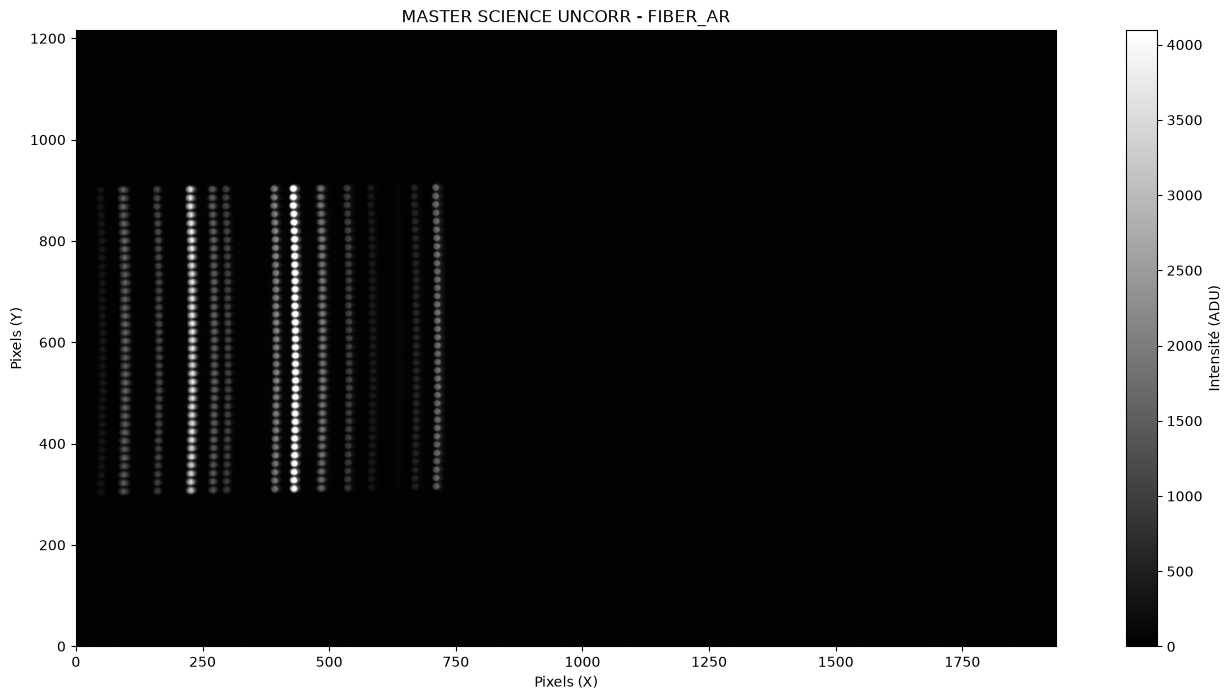

In [18]:
%matplotlib inline
# %matplotlib qt
fig, ax = plt.subplots(figsize=(18,8))

im = ax.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower', vmin=0)#, vmax=2000)

ax.set_title(f"MASTER SCIENCE UNCORR - {OBJECT_NAME}")
ax.set_xlabel("Pixels (X)")
ax.set_ylabel("Pixels (Y)")

# 5. Ajout de la barre de couleur liée à l'image 'im'
fig.colorbar(im, ax=ax, label="Intensité (ADU)")

plt.show()

In [19]:

img_min = MASTER_SCIENCE_UNCORR.min()
img_max = MASTER_SCIENCE_UNCORR.max()

if img_max > img_min:
    # Scale to 0.0 - 255.0 float
    img_scaled = 255.0 * (MASTER_SCIENCE_UNCORR - img_min) / (img_max - img_min)
else:
    img_scaled = np.zeros_like(MASTER_SCIENCE_UNCORR)

# 2. Cast to uint8 (CV_8UC1)
img_8bit = img_scaled.astype(np.uint8)

gray = cv2.GaussianBlur(img_8bit, (3, 3), 0)  
#img_8bit#cv2.medianBlur(img_8bit,5)


In [20]:
circles = cv2.HoughCircles(
    gray,                     # Ton image modifiée (en uint8 + CLAHE)
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=8,                # Baissé de 10 à 6 car les points sont très serrés verticalement
    param1=35,                # Seuil Canny bas pour détecter les colonnes les plus sombres
    param2=4,                # Crucial ! Baissé drastiquement de 100 à 11-13.
    minRadius=5,              # Rayon minimal (très petit pour ces fibres)
    maxRadius=8              # Rayon maximal (ajusté d'après ton axe des pixels)
)



output = gray.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point

# Show result
# cv2.imshow('Detected Circle', output)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
circles

circles[0]
print(np.shape(circles[0])[0])


481


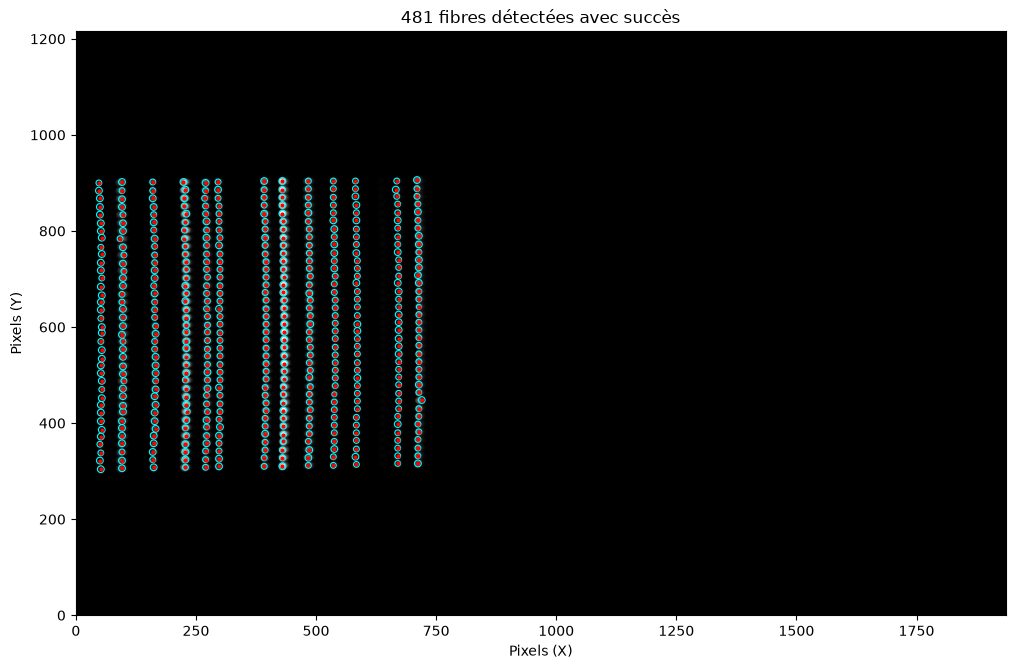

In [21]:
# %matplotlib qt
%matplotlib inline
plt.figure(figsize=(12, 8))
plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower') 

n_circ = np.shape(circles[0])[0]
xcirc_arr = np.zeros(n_circ)
ycirc_arr = np.zeros(n_circ)
radius_arr = np.zeros(n_circ)

if circles is not None:
    circles_list = circles[0]
    for i, c in enumerate(circles_list):
        x, y, r = c[0], c[1], c[2]
        xcirc_arr[i], ycirc_arr[i], radius_arr[i] = x, y, r
        plt.plot(x, y, 'ro', markersize=2)
        circle_plot = plt.Circle((x, y), r, color='cyan', fill=False, linewidth=0.8)
        plt.gca().add_patch(circle_plot)

plt.title(f"{len(circles_list)} fibres détectées avec succès")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.show()

In [22]:
import pandas as pd
import numpy as np

# 1. On met les données dans un DataFrame
df = pd.DataFrame(circles[0], columns=['X', 'Y', 'R'])

# 2. ÉTAPE A : Séparer les grandes colonnes verticales (selon l'axe X, de gauche à droite)
df = df.sort_values(by='X').reset_index(drop=True)
# Si l'écart en X entre deux points est > 15 pixels, c'est une nouvelle colonne verticale
df['colonne_id'] = (df['X'].diff() > 15).cumsum()

# 3. ÉTAPE B : Numéroter les 37 fibres de bas en haut à l'intérieur de chaque colonne
# On trie chaque groupe par sa coordonnée Y, et on lui attribue un index de 1 à 37
df = df.sort_values(by=['colonne_id', 'Y']).reset_index(drop=True)
df['fiber_id'] = df.groupby('colonne_id').cumcount() + 1

# 4. Vérification des paquets
print(f"Nombre de colonnes verticales détectées : {df['colonne_id'].nunique()}")
print("\nVérification du nombre de fibres par colonne :")
print(df.groupby('colonne_id').size())

Nombre de colonnes verticales détectées : 13

Vérification du nombre de fibres par colonne :
colonne_id
0     37
1     37
2     37
3     37
4     37
5     37
6     37
7     37
8     37
9     37
10    37
11    37
12    37
dtype: int64


In [23]:
import pandas as pd
import numpy as np

# On repart du DataFrame brut extrait des cercles
df = pd.DataFrame(circles[0], columns=['X', 'Y', 'R'])
df = df.sort_values(by='X').reset_index(drop=True)

# 1. Séparation initiale en colonnes (seuil de 15 pixels)
df['colonne_id'] = (df['X'].diff() > 15).cumsum()

# 2. NETTOYAGE : On filtre chaque colonne pour ne garder que les 37 meilleurs points
df_cleaned_list = []

for col_id, group in df.groupby('colonne_id'):
    # Si le groupe a déjà 37 points, il est parfait
    if len(group) == 37:
        df_cleaned_list.append(group)
    # Si le groupe a trop de points, on fait le ménage
    elif len(group) > 37:
        # Étape A : On vire les points qui s'écartent trop du X moyen de la colonne
        x_median = group['X'].median()
        group['dist_to_center'] = np.abs(group['X'] - x_median)
        # On ne garde que les points les plus proches de l'alignement vertical
        group = group.sort_values(by='dist_to_center').head(37)
        df_cleaned_list.append(group.drop(columns=['dist_to_center']))
    else:
        # Au cas où une colonne aurait moins de 37 points (pas le cas ici)
        df_cleaned_list.append(group)

# Reconstitution du DataFrame propre
df_clean = pd.concat(df_cleaned_list).reset_index(drop=True)

# 3. Indexation finale des 37 fibres de bas en haut
df_clean = df_clean.sort_values(by=['colonne_id', 'Y']).reset_index(drop=True)
df_clean['fiber_id'] = df_clean.groupby('colonne_id').cumcount() + 1

# 4. Vérification finale
print("Vérification après nettoyage :")
print(df_clean.groupby('colonne_id').size())

Vérification après nettoyage :
colonne_id
0     37
1     37
2     37
3     37
4     37
5     37
6     37
7     37
8     37
9     37
10    37
11    37
12    37
dtype: int64


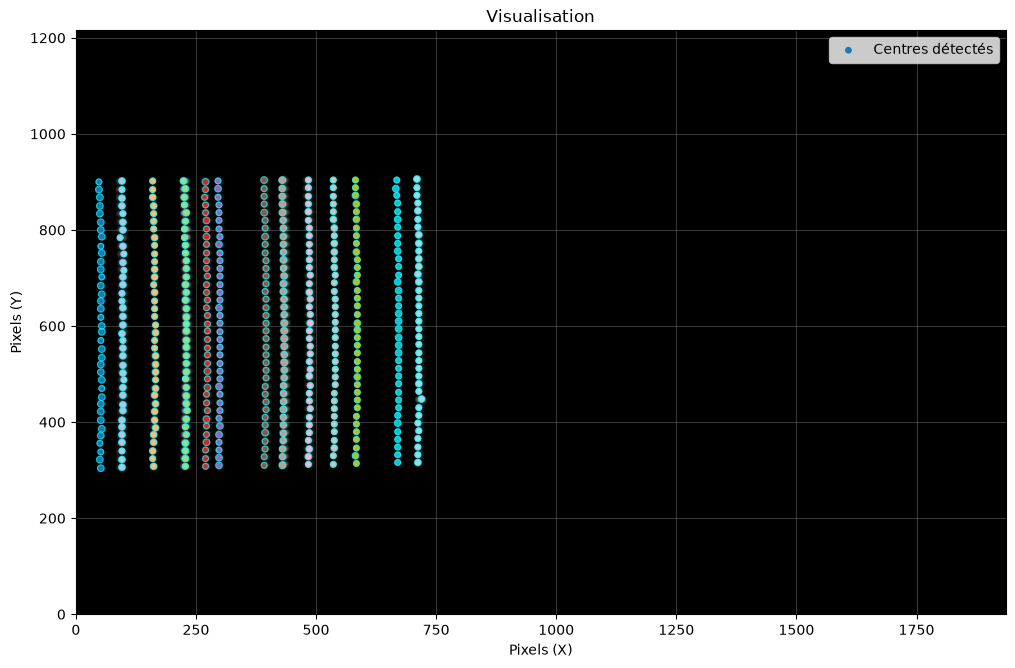

In [24]:
from matplotlib.patches import Circle

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower') 


ax = plt.gca()
sc = ax.scatter(df_clean['X'], df_clean['Y'], c=df_clean['colonne_id'], cmap='tab20', s=15, label='Centres détectés', zorder=4)

for _, row in df_clean.iterrows():
    circ = Circle((row['X'], row['Y']), row['R'], edgecolor='cyan', facecolor='none', linewidth=0.8, alpha=0.7, zorder=5)
    ax.add_patch(circ)

ax.legend()

plt.title("Visualisation")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   X           481 non-null    uint16
 1   Y           481 non-null    uint16
 2   R           481 non-null    uint16
 3   colonne_id  481 non-null    int64 
 4   fiber_id    481 non-null    int64 
dtypes: int64(2), uint16(3)
memory usage: 10.5 KB


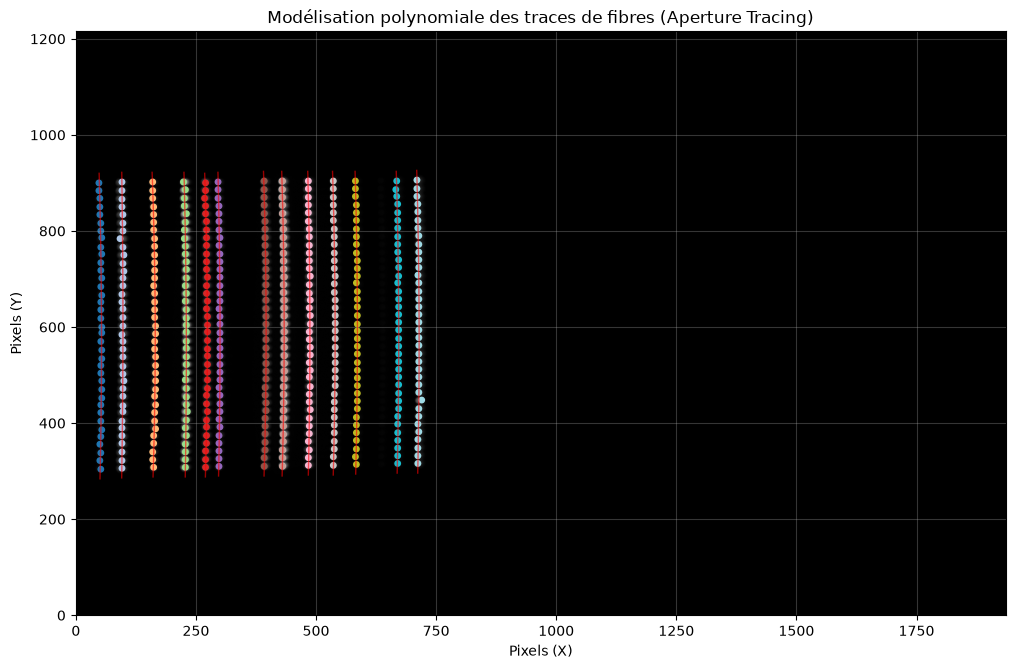

Coefficients de la colonne 0 (dans l'ordre décroissant des degrés) :
[-4.00938692e-05  4.54928332e-02  4.05541740e+01]


In [26]:
import matplotlib.pyplot as plt

# 1. Préparation du dictionnaire pour stocker les coefficients de chaque colonne
coefficients_colonnes = {}

plt.figure(figsize=(12, 8))
plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower') 

# On affiche les points nettoyés
plt.scatter(df_clean['X'], df_clean['Y'], c=df_clean['colonne_id'], cmap='tab20', s=15, label='Centres détectés')

# 2. Boucle sur chaque colonne pour ajuster le polynôme
for col_id, group in df_clean.groupby('colonne_id'):
    # On ajuste X en fonction de Y (car la trace est verticale)
    # Un degré 2 (ax^2 + bx + c) suffit généralement, passe à 3 si la distorsion est en S
    poly_coeffs = np.polyfit(group['Y'], group['X'], deg=2)
    coefficients_colonnes[col_id] = poly_coeffs
    
    # Générer des points lissés en Y pour tracer la ligne continue du fit
    y_fit = np.linspace(group['Y'].min() - 20, group['Y'].max() + 20, 100)
    x_fit = np.polyval(poly_coeffs, y_fit)
    
    # Tracer la ligne de la trace de la colonne
    plt.plot(x_fit, y_fit, color='red', alpha=0.6, linewidth=1)

plt.title("Modélisation polynomiale des traces de fibres (Aperture Tracing)")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.grid(True, alpha=0.3)
plt.show()

# Exemple pour afficher les coefficients de la première colonne
print("Coefficients de la colonne 0 (dans l'ordre décroissant des degrés) :")
print(coefficients_colonnes[0])

## Caractérisation du FWHM (X et Y) pour chaque point (cercle) détectées

In [27]:
print(len(MASTER_SCIENCE_UNCORR[:,0]))

1216


In [28]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from tqdm import tqdm

def gaussian(x, amplitude, mean, stddev, background):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + background

# 1. On applique ton filtre sur le colonne_id si c'est ce df que tu veux itérer
# mask_col = df_clean['colonne_id'] == 1
# df_filtered = df_clean[mask_col]

results_list = []

# Itération sur le dataframe filtré
for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    # Sécurité pour NumPy : conversion en entiers
    x = int(row['X'])
    y = int(row['Y'])
    r = int(row['R'])
    
    x_line = MASTER_SCIENCE_UNCORR[y, x - 2*r : x + 2*r]
    y_line = MASTER_SCIENCE_UNCORR[y - r : y + r, x]
    
    x_axis = np.arange(x - 2*r, x + 2*r)
    y_axis = np.arange(y - r, y + r)
    
    # Vérification anti-plantage si on est en bord d'image (tableaux vides ou de tailles différentes)
    # if len(x_line) != len(x_axis) or len(y_line) != len(y_axis) or len(x_line) == 0:
    #     continue

    # Estimations initiales (p0)
    p0_x = [np.max(x_line), x, r / 2, np.min(x_line)]
    p0_y = [np.max(y_line), y, r / 2, np.min(y_line)]
    
    # Bornes (bounds) adaptées à 4 paramètres : [amplitude, mean, stddev, background]
    # On autorise le centre à bouger de maximum +/- r autour de la position initiale
    bounds_x = (
        [0,              x - r,  0.3,   0],             # Bornes minimales
        [p0_x[0] * 10,   x + r,  4 * r, np.max(x_line)]  # Bornes maximales
    )
    bounds_y = (
        [0,              y - r,  0.3,   0],             # Bornes minimales
        [p0_y[0] * 10,   y + r,  4 * r, np.max(y_line)]  # Bornes maximales
    )
    
    try:
        # Ajustements avec p0 et bounds associés
        popt_x, _ = curve_fit(gaussian, x_axis, x_line, p0=p0_x, bounds=bounds_x)
        popt_y, _ = curve_fit(gaussian, y_axis, y_line, p0=p0_y, bounds=bounds_y)

        row_results = {
            'original_index': idx,
            'X_init': x,
            'Y_init': y,
            'R_init': r,
            
            # Résultats profils X
            'amp_x': popt_x[0],
            'X_fitted': popt_x[1], 
            'fwhm_x': 2.355 * popt_x[2],
            'bg_x': popt_x[3],

            # Résultats profils Y
            'amp_y': popt_y[0],
            'Y_fitted': popt_y[1],
            'fwhm_y': 2.355 * popt_y[2],
            'bg_y': popt_y[3],
            'colonne_id' : row['colonne_id']
        }
        
        results_list.append(row_results)
        
    except (RuntimeError, ValueError):
        print(':(')
        # On ignore si le fit ne converge pas ou si les bounds sont incompatibles
        # continue

# Création du DataFrame final
df_results = pd.DataFrame(results_list)

100%|██████████| 481/481 [00:02<00:00, 186.80it/s]


In [29]:
df_results

,original_index,X_init,Y_init,R_init,amp_x,X_fitted,fwhm_x,bg_x,amp_y,Y_fitted,fwhm_y,bg_y,colonne_id
0,0,52,304,7,334.717131,49.850342,13.006260,7.394886e+00,333.337832,304.974441,13.257432,2.831777e-13,0
1,1,50,322,7,360.774045,49.721466,12.835920,7.163977e+00,362.888544,321.585055,14.408362,3.104286e-10,0
2,2,52,338,6,373.492010,50.104573,13.061035,2.698684e-15,359.916052,338.065497,13.763046,7.235640e-10,0
3,3,50,356,6,352.863778,50.663559,12.944101,2.150106e-13,347.382396,354.657331,15.102285,8.609733e-17,0
4,4,52,372,7,396.276931,51.283704,13.102004,1.086758e+00,388.213404,371.323632,14.217131,1.955298e-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,476,712,840,7,1904.880251,712.603625,12.387470,3.871556e-10,1769.489592,838.926241,15.580934,1.579716e-14,12
477,477,712,856,6,1771.499373,712.184102,12.152187,1.050294e-09,1630.806693,856.003187,20.258904,8.272831e-11,12
478,478,710,872,6,1907.286735,711.251959,12.487701,1.462459e-13,1711.301431,873.164373,18.816528,1.231278e-12,12
479,479,710,888,6,1793.808575,711.316455,12.400334,4.835105e-15,1605.207687,889.252494,18.031865,2.959696e-14,12


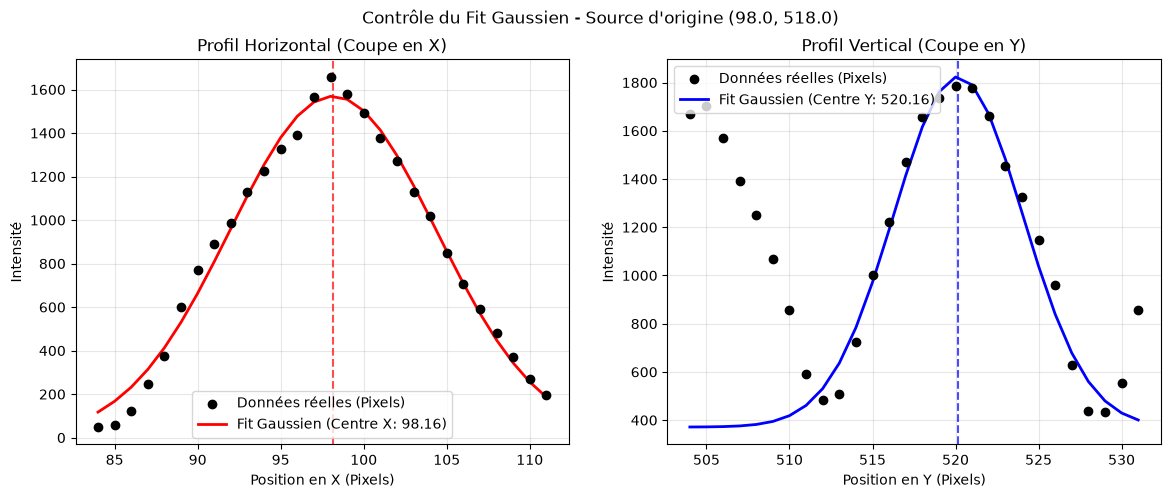

In [30]:
import matplotlib.pyplot as plt

# On prend la première ligne de nos résultats pour l'exemple
sample = df_results.iloc[50]

# 1. Reconstruction des axes pixelliques d'origine
r = int(sample['R_init'])
x_axis = np.arange(int(sample['X_init']) - 2*r, int(sample['X_init']) + 2*r)
y_axis = np.arange(int(sample['Y_init']) - 2*r, int(sample['Y_init']) + 2*r)

# 2. Récupération des profils réels dans ton image de science
x_line_real = MASTER_SCIENCE_UNCORR[int(sample['Y_init']), int(sample['X_init']) - 2*r : int(sample['X_init']) + 2*r]
y_line_real = MASTER_SCIENCE_UNCORR[int(sample['Y_init']) - 2*r : int(sample['Y_init']) + 2*r, int(sample['X_init'])]

# 3. Génération des courbes gaussiennes fittées
# Rappel des paramètres : (x, amplitude, mean, stddev, background)
# fwhm = 2.355 * stddev -> stddev = fwhm / 2.355
x_fit_curve = gaussian(x_axis, sample['amp_x'], sample['X_fitted'], sample['fwhm_x']/2.355, sample['bg_x'])
y_fit_curve = gaussian(y_axis, sample['amp_y'], sample['Y_fitted'], sample['fwhm_y']/2.355, sample['bg_y'])

# --- Tracé Matplotlib ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Profil Horizontal (X)
ax1.scatter(x_axis, x_line_real, color='black', label='Données réelles (Pixels)', zorder=3)
ax1.plot(x_axis, x_fit_curve, color='red', label=f"Fit Gaussien (Centre X: {sample['X_fitted']:.2f})", linewidth=2)
ax1.axvline(sample['X_fitted'], color='red', linestyle='--', alpha=0.7)
ax1.set_title("Profil Horizontal (Coupe en X)")
ax1.set_xlabel("Position en X (Pixels)")
ax1.set_ylabel("Intensité")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Profil Vertical (Y)
ax2.scatter(y_axis, y_line_real, color='black', label='Données réelles (Pixels)', zorder=3)
ax2.plot(y_axis, y_fit_curve, color='blue', label=f"Fit Gaussien (Centre Y: {sample['Y_fitted']:.2f})", linewidth=2)
ax2.axvline(sample['Y_fitted'], color='blue', linestyle='--', alpha=0.7)
ax2.set_title("Profil Vertical (Coupe en Y)")
ax2.set_xlabel("Position en Y (Pixels)")
ax2.set_ylabel("Intensité")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Contrôle du Fit Gaussien - Source d'origine ({sample['X_init']}, {sample['Y_init']})")
plt.show()

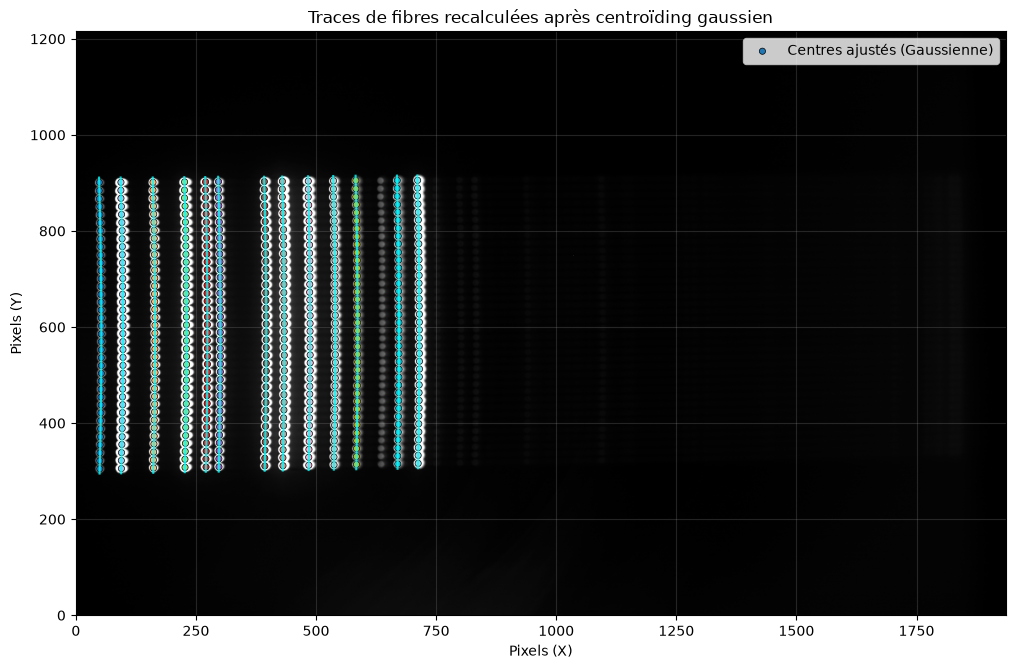

In [31]:
# On fusionne df_results avec df_clean pour récupérer la colonne_id de chaque point fitté
# df_viz = df_results.merge(df_results[['colonne_id']], left_on='original_index', right_index=True)
df_viz = df_results.copy()

# On va chercher 'colonne_id' dans df_clean là où l'index correspond à original_index
df_viz['colonne_id'] = df_clean.loc[df_results['original_index'], 'colonne_id'].values

plt.figure(figsize=(12, 8))
plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower', vmin=np.percentile(MASTER_SCIENCE_UNCORR, 5), vmax=np.percentile(MASTER_SCIENCE_UNCORR, 95)) 

# 1. On affiche les NOUVEAUX centres ultra-précis trouvés par la gaussienne
plt.scatter(df_viz['X_fitted'], df_viz['Y_fitted'], c=df_viz['colonne_id'], cmap='tab20', s=20, edgecolors='black', linewidths=0.5, label='Centres ajustés (Gaussienne)')

coefficients_colonnes = {}

# 2. Boucle sur chaque colonne en utilisant les coordonnées FITTÉES
for col_id, group in df_viz.groupby('colonne_id'):
    # Ajustement polynomial du profil de la fibre (X_fitted en fonction de Y_fitted)
    poly_coeffs = np.polyfit(group['Y_fitted'], group['X_fitted'], deg=2)
    coefficients_colonnes[col_id] = poly_coeffs
    
    # Ligne continue du fit
    y_fit = np.linspace(group['Y_fitted'].min() - 10, group['Y_fitted'].max() + 10, 100)
    x_fit = np.polyval(poly_coeffs, y_fit)
    
    plt.plot(x_fit, y_fit, color='cyan', alpha=0.8, linewidth=1.5)

plt.title("Traces de fibres recalculées après centroïding gaussien")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

---

In [32]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# def gaussian(x, amplitude, mean, stddev, background):
#     return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) + background

# half_window = 5
# subpixel_37_data = []

# # On boucle sur les 37 points de OpenCV pour chaque colonne
# for col_id, group in df_clean.groupby('colonne_id'):
#     for idx, row in group.iterrows():
#         x_int = int(row['X'])
#         y_int = int(row['Y']) # On ne prend QUE les Y des cercles OpenCV
        
#         # Fenêtre de pixels en X autour du cercle
#         x_indices = np.arange(x_int - half_window, x_int + half_window + 1)
        
#         if x_indices[0] < 0 or x_indices[-1] >= MASTER_SCIENCE_UNCORR.shape[1]:
#             continue
            
#         intensity_profile = MASTER_SCIENCE_UNCORR[y_int, x_indices]
        
#         p0 = [np.max(intensity_profile) - np.min(intensity_profile), x_int, 1.5, np.min(intensity_profile)]
        
#         try:
#             popt, _ = curve_fit(gaussian, x_indices, intensity_profile, p0=p0, maxfev=1000)
#             x_subpixel = popt[1]
            
#             if abs(x_subpixel - x_int) < 3:
#                 subpixel_37_data.append({'colonne_id': col_id, 'X_sub': x_subpixel, 'Y': y_int})
#         except RuntimeError:
#             # En cas d'échec du fit, on garde la position OpenCV d'origine pour ne pas perdre le point
#             subpixel_37_data.append({'colonne_id': col_id, 'X_sub': row['X'], 'Y': y_int})

# df_subpixel_37 = pd.DataFrame(subpixel_37_data)

# # Vérification : chaque colonne aura maintenant exactement 37 points sub-pixel !
# print(df_subpixel_37.groupby('colonne_id').size())

In [33]:
# %matplotlib qt
# # 1. Dictionnaire pour stocker les coefficients sub-pixel finaux
# coefficients_subpixel_finaux = {}

# plt.figure(figsize=(12, 8))
# plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower') 

# # 2. Affichage des 37 points sub-pixel par colonne
# # On augmente la taille (s=25) puisqu'il n'y a plus que 37 points nets par fibre
# plt.scatter(
#     df_subpixel_37['X_sub'], 
#     df_subpixel_37['Y'], 
#     c=df_subpixel_37['colonne_id'], 
#     cmap='tab20', 
#     s=25, 
#     edgecolors='black', 
#     linewidths=0.5,
#     zorder=3,
#     label='Centres Sub-pixel (37 par colonne)'
# )

# # 3. Boucle pour ajuster et tracer les polynômes continus
# for col_id, group in df_subpixel_37.groupby('colonne_id'):
#     # Ajustement polynomial (X_sub en fonction de Y) sur tes 37 points précis
#     poly_coeffs = np.polyfit(group['Y'], group['X_sub'], deg=2)
#     coefficients_subpixel_finaux[col_id] = poly_coeffs
    
#     # Génération de la ligne continue pour le graphique
#     y_fit = np.linspace(group['Y'].min() - 20, group['Y'].max() + 20, 200)
#     x_fit = np.polyval(poly_coeffs, y_fit)
    
#     # Tracé du profil de la fente / fibre
#     plt.plot(x_fit, y_fit, color='red', alpha=0.8, linewidth=1.5, zorder=2)

# plt.title("Modélisation polynomiale sub-pixel finale (37 points par trace)")
# plt.xlabel("Pixels (X)")
# plt.ylabel("Pixels (Y)")
# plt.grid(True, alpha=0.3, zorder=1)

# # Gestion de la légende pour éviter les doublons
# plt.legend(loc='upper right')
# plt.show()

# # Affichage des paramètres ajustés pour vérification
# print("Coefficients sub-pixel finaux pour la colonne 0 (ax^2 + bx + c) :")
# print(coefficients_subpixel_finaux[0])

In [35]:
df_results

,original_index,X_init,Y_init,R_init,amp_x,X_fitted,fwhm_x,bg_x,amp_y,Y_fitted,fwhm_y,bg_y,colonne_id
0,0,52,304,7,334.717131,49.850342,13.006260,7.394886e+00,333.337832,304.974441,13.257432,2.831777e-13,0
1,1,50,322,7,360.774045,49.721466,12.835920,7.163977e+00,362.888544,321.585055,14.408362,3.104286e-10,0
2,2,52,338,6,373.492010,50.104573,13.061035,2.698684e-15,359.916052,338.065497,13.763046,7.235640e-10,0
3,3,50,356,6,352.863778,50.663559,12.944101,2.150106e-13,347.382396,354.657331,15.102285,8.609733e-17,0
4,4,52,372,7,396.276931,51.283704,13.102004,1.086758e+00,388.213404,371.323632,14.217131,1.955298e-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,476,712,840,7,1904.880251,712.603625,12.387470,3.871556e-10,1769.489592,838.926241,15.580934,1.579716e-14,12
477,477,712,856,6,1771.499373,712.184102,12.152187,1.050294e-09,1630.806693,856.003187,20.258904,8.272831e-11,12
478,478,710,872,6,1907.286735,711.251959,12.487701,1.462459e-13,1711.301431,873.164373,18.816528,1.231278e-12,12
479,479,710,888,6,1793.808575,711.316455,12.400334,4.835105e-15,1605.207687,889.252494,18.031865,2.959696e-14,12


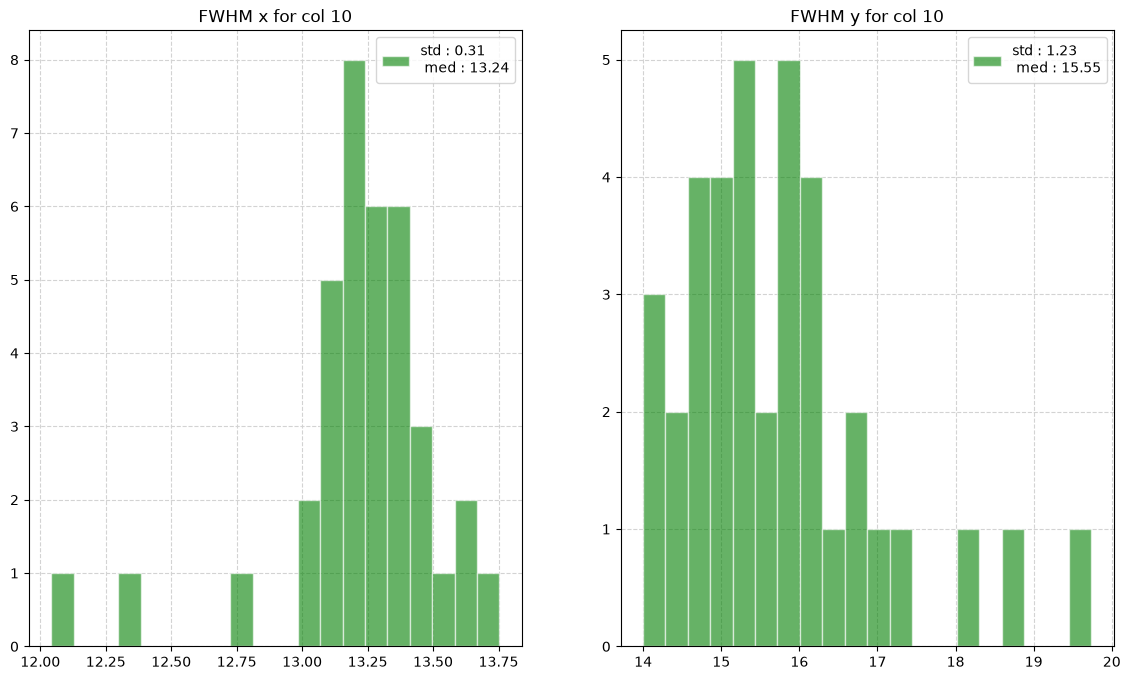

In [62]:
i_col = 10
mask_col = df_results['colonne_id'] == i_col
# df_results

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,8))
ax1.grid(ls='--',c='lightgrey')
ax1.hist(df_results['fwhm_x'][mask_col],bins=20,edgecolor='white',color='green',alpha=0.6,label=f'std : {np.std(df_results['fwhm_x'][mask_col]):.2f}\n med : {np.median(df_results['fwhm_x'][mask_col]):.2f}')
ax1.set_axisbelow(True)
ax1.set_title(f'FWHM x for col {i_col}')
ax1.legend()

ax2.grid(ls='--',c='lightgrey')
ax2.hist(df_results['fwhm_y'][mask_col],bins=20,edgecolor='white',color='green',alpha=0.6,label=f'std : {np.std(df_results['fwhm_y'][mask_col]):.2f}\n med : {np.median(df_results['fwhm_y'][mask_col]):.2f}')
ax2.set_axisbelow(True)
ax2.set_title(f'FWHM y for col {i_col}')
ax2.legend()

plt.show()
# ax.hist(df_results['fwhm_y'][mask_col],bins=30)

In [ ]:
i_col = 8
mask_col = df_results['colonne_id'] == i_col
# df_results

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,8))
ax1.grid(ls='--',c='lightgrey')
ax1.hist(df_results['fwhm_x'][mask_col],bins=20,edgecolor='white',color='green',alpha=0.6,label=f'std : {np.std(df_results['fwhm_x'][mask_col]):.2f}\n med : {np.median(df_results['fwhm_x'][mask_col]):.2f}')
ax1.set_axisbelow(True)
ax1.set_title(f'FWHM x for col {i_col}')
ax1.legend()

ax2.grid(ls='--',c='lightgrey')
ax2.hist(df_results['fwhm_y'][mask_col],bins=20,edgecolor='white',color='green',alpha=0.6,label=f'std : {np.std(df_results['fwhm_y'][mask_col]):.2f}\n med : {np.median(df_results['fwhm_y'][mask_col]):.2f}')
ax2.set_axisbelow(True)
ax2.set_title(f'FWHM y for col {i_col}')
ax2.legend()

plt.show()
# ax.hist(df_results['fwhm_y'][mask_col],bins=30)

In [46]:
from ipywidgets import Dropdown
from IPython.display import display
%matplotlib qt
# 1. Préparation de la figure à deux sous-graphiques (Fit | Résidus)
fig, (ax_fit, ax_res) = plt.subplots(1, 2, figsize=(14, 6))
plt.subplots_adjust(bottom=0.2)

def update_plots(col_id):
    """Fonction qui rafraîchit les graphiques quand on change de colonne"""
    ax_fit.clear()
    ax_res.clear()

    group = df_results[df_results['colonne_id'] == col_id].sort_values('Y_fitted')
    y_data = group['Y_fitted'].values
    x_data = group['X_fitted'].values

    poly_coeffs = np.polyfit(y_data, x_data, deg=2)
    y_fit = np.linspace(y_data.min() - 10, y_data.max() + 10, 200)
    x_fit = np.polyval(poly_coeffs, y_fit)

    x_pred = np.polyval(poly_coeffs, y_data)
    residus = x_data - x_pred
    rms = np.sqrt(np.mean(residus**2))

    ax_fit.scatter(x_data, y_data, color='black', s=30, label='Centres sub-pixel', zorder=3)
    ax_fit.plot(x_fit, y_fit, color='red', linewidth=1.5, label='Fit (Degré 2)', zorder=2)
    ax_fit.set_title(f"Colonne {col_id} : Ajustement de la trace")
    ax_fit.set_xlabel("Pixels (X)")
    ax_fit.set_ylabel("Pixels (Y)")
    ax_fit.grid(True, alpha=0.3)
    ax_fit.legend()

    ax_res.scatter(y_data, residus, color='crimson', s=40, edgecolors='black', linewidths=0.5)
    ax_res.axhline(0, color='black', linestyle='--', alpha=0.7)

    max_res = max(np.max(np.abs(residus)), 0.1)
    ax_res.set_ylim(-max_res * 1.2, max_res * 1.2)

    ax_res.set_title(f"Résidus de la colonne {col_id} (RMS = {rms:.3f} px)")
    ax_res.set_xlabel("Pixels (Y)")
    ax_res.set_ylabel("Écart ΔX (Pixels)")
    ax_res.grid(True, alpha=0.3)

    fig.canvas.draw_idle()

liste_colonnes = sorted(df_results['colonne_id'].unique())
dropdown = Dropdown(options=liste_colonnes, description='Colonne :')
display(dropdown)

def on_change(change):
    if change["name"] == "value":
        update_plots(change["new"])

dropdown.observe(on_change, names="value")

update_plots(liste_colonnes[0])
plt.show()

Dropdown(description='Colonne :', options=(np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np…

In [63]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.widgets import Slider

# # On suppose que tu as déjà calculé 'coefficients_subpixel_finaux' (dictionnaire avec les 13 clés)
# # Choisissons une ligne Y de départ au milieu de l'image
# y_init = int(MASTER_SCIENCE_UNCORR.shape[0] / 2)

# fig, ax = plt.subplots(figsize=(14, 6))
# plt.subplots_adjust(bottom=0.25) # Place pour le slider

# # Fonction pour récupérer les positions X théoretiques de toutes les colonnes à une hauteur Y
# def get_all_x_positions(y_val):
#     x_positions = []
#     for col_id in sorted(coefficients_subpixel_finaux.keys()):
#         coeffs = coefficients_subpixel_finaux[col_id]
#         x_calc = np.polyval(coeffs, y_val)
#         x_positions.append((col_id, x_calc))
#     return x_positions

# # --- DESSIN INITIAL ---
# # 1. Profil d'intensité réel de l'image à la ligne y_init
# profil_intensite = MASTER_SCIENCE_UNCORR[y_init, :]
# line_profil, = ax.plot(profil_intensite, color='black', linewidth=1, label=f'Profil réel (Ligne Y = {y_init})')

# # 2. Ajout des lignes verticales pour chaque fibre trouvée par les polynômes
# vlines_positions = get_all_x_positions(y_init)
# lines_verticales = []
# textes_labels = []

# for col_id, x_pos in vlines_positions:
#     # Ligne pointillée au centre prédit de la fibre
#     vl = ax.axvline(x=x_pos, color='red', linestyle='--', alpha=0.7, linewidth=1)
#     lines_verticales.append(vl)
    
#     # Petit texte pour identifier la colonne au-dessus du pic
#     txt = ax.text(x_pos, np.max(profil_intensite)*1.02, f"C{col_id}", 
#                   color='crimson', fontsize=9, ha='center', va='bottom')
#     textes_labels.append(txt)

# ax.set_title("Coupe horizontale : Validation des fits polynomiaux sur le profil des fibres")
# ax.set_xlabel("Position en X (Pixels)")
# ax.set_ylabel("Flux / Intensité (ADU)")
# ax.grid(True, alpha=0.2)
# ax.set_xlim(df_subpixel_37['X_sub'].min() - 20, df_subpixel_37['X_sub'].max() + 20)
# # Laisser un peu d'espace en haut pour les étiquettes C0, C1...
# ax.set_ylim(np.min(profil_intensite), np.max(profil_intensite) * 1.15) 

# # --- AJOUT DU SLIDER INTERACTIF ---
# ax_slider = plt.axes([0.15, 0.1, 0.7, 0.03])
# slider_y = Slider(
#     ax_slider, 'Ligne Y', 
#     valmin=int(df_subpixel_37['Y'].min()), 
#     valmax=int(df_subpixel_37['Y'].max()), 
#     valinit=y_init, valfmt='%d', color='teal'
# )

# # Fonction de mise à jour lors du déplacement du slider
# def update(val):
#     y_current = int(slider_y.val)
    
#     # 1. Mettre à jour le profil d'intensité réel
#     new_profile = MASTER_SCIENCE_UNCORR[y_current, :]
#     line_profil.set_ydata(new_profile)
#     line_profil.set_label(f'Profil réel (Ligne Y = {y_current})')
    
#     # Ajuster l'échelle en Y dynamiquement si l'intensité change selon la hauteur
#     ax.set_ylim(np.min(new_profile), np.max(new_profile) * 1.15)
    
#     # 2. Mettre à jour la position des lignes verticales et des textes
#     current_positions = get_all_x_positions(y_current)
#     for i, (col_id, x_pos) in enumerate(current_positions):
#         lines_verticales[i].set_xdata([x_pos, x_pos])
#         textes_labels[i].set_x(x_pos)
#         textes_labels[i].set_y(np.max(new_profile) * 1.02)
        
#     fig.canvas.draw_idle()

# slider_y.on_changed(update)
# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from ipywidgets import Dropdown  # Correction de l'import pour utiliser ipywidgets
# from IPython.display import display

# # On s'assure que les données sont bien triées pour le fit
# # 1. On crée le fiber_id en triant par colonne, puis par hauteur Y
# # On attribue un rang de 1 à 37 pour chaque élément de la colonne
# df_subpixel_37['fiber_id'] = df_subpixel_37.groupby('colonne_id')['Y'].rank(method='first').astype(int)

# # Vérification rapide : chaque colonne doit maintenant avoir des fibres de 1 à 37
# print("Vérification du nombre de fibres par ID :")
# print(df_subpixel_37['fiber_id'].value_counts().sort_index())
# df_subpixel_37 = df_subpixel_37.sort_values(by=['fiber_id', 'colonne_id'])

# # Dictionnaire pour stocker les coefficients horizontaux
# coefficients_horizontaux = {}

# fig, (ax_fit, ax_res) = plt.subplots(1, 2, figsize=(14, 6))
# plt.subplots_adjust(bottom=0.2)

# def update_horizontal_plots(fiber_id):
#     ax_fit.clear()
#     ax_res.clear()

#     # Correction : On utilise 'X_sub' car la colonne 'X' brute n'existe plus
#     group = df_subpixel_37[df_subpixel_37['fiber_id'] == fiber_id].sort_values('X_sub')

#     x_data = group['X_sub'].values
#     y_data = group['Y'].values

#     poly_coeffs = np.polyfit(x_data, y_data, deg=2)
#     coefficients_horizontaux[fiber_id] = poly_coeffs

#     x_fit = np.linspace(df_subpixel_37['X_sub'].min() - 10,
#                         df_subpixel_37['X_sub'].max() + 10, 200)
#     y_fit = np.polyval(poly_coeffs, x_fit)

#     y_pred = np.polyval(poly_coeffs, x_data)
#     residus = y_data - y_pred
#     rms = np.sqrt(np.mean(residus**2))

#     ax_fit.scatter(x_data, y_data, color='black', s=40, edgecolors='k', zorder=3)
#     ax_fit.plot(x_fit, y_fit, color='blue', linewidth=1.5, zorder=2)
#     ax_fit.set_title(f"Fibre {fiber_id} : Alignement horizontal")
#     ax_fit.set_xlabel("Pixels (X)")
#     ax_fit.set_ylabel("Pixels (Y)")
#     ax_fit.grid(True, alpha=0.3)

#     ax_res.scatter(x_data, residus, color='darkviolet', s=50, edgecolors='black', linewidths=0.5)
#     ax_res.axhline(0, color='black', linestyle='--', alpha=0.7)

#     max_res = max(np.max(np.abs(residus)), 0.1)
#     ax_res.set_ylim(-max_res * 1.3, max_res * 1.3)
#     ax_res.set_title(f"Résidus - Fibre {fiber_id} (RMS = {rms:.3f} px)")
#     ax_res.set_xlabel("Pixels (X)")
#     ax_res.set_ylabel(r"Écart $\Delta Y$ (Pixels)")
#     ax_res.grid(True, alpha=0.3)

#     fig.canvas.draw_idle()

# liste_fibres = sorted(df_subpixel_37['fiber_id'].unique())

# # Correction : On utilise la syntaxe standard d'ipywidgets pour le Dropdown
# dropdown = Dropdown(
#     options=liste_fibres,
#     value=liste_fibres[0],
#     description='Fibre :'
# )

# def on_change(change):
#     if change["name"] == "value":
#         update_horizontal_plots(change["new"])

# dropdown.observe(on_change, names="value")

# display(dropdown)
# update_horizontal_plots(liste_fibres[0])
# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. CORRECTION DES IDS : On groupe par le rang réel des Y sur l'ensemble de l'image
# # On trie d'abord par Y pour être sûr de l'ordre vertical global
# df_subpixel_37 = df_subpixel_37.sort_values('Y')

# # On crée 37 groupes verticaux (bins) basés sur la position Y de chaque point
# df_subpixel_37['fiber_id'] = pd.qcut(df_subpixel_37['Y'], q=37, labels=range(1, 38)).astype(int)

# # 2. Recalcul des coefficients horizontaux avec les bons IDs
# coefficients_horizontaux_complet = {}
# for fiber_id, group in df_subpixel_37.groupby('fiber_id'):
#     group_sorted = group.sort_values('X_sub')
#     poly_coeffs = np.polyfit(group_sorted['X_sub'].values, group_sorted['Y'].values, deg=2)
#     coefficients_horizontaux_complet[fiber_id] = poly_coeffs

# # 3. Tracé du graphique complet
# plt.figure(figsize=(14, 10))

# plt.imshow(MASTER_SCIENCE_UNCORR, cmap='gray', origin='lower', 
#            vmin=np.percentile(MASTER_SCIENCE_UNCORR, 5), 
#            vmax=np.percentile(MASTER_SCIENCE_UNCORR, 95))

# x_min_reel = int(df_subpixel_37['X_sub'].min()) - 5
# x_max_reel = int(df_subpixel_37['X_sub'].max()) + 5
# x_espace = np.linspace(x_min_reel, x_max_reel, 200)

# cmap = plt.colormaps.get_cmap('rainbow')
# nb_fibres = len(coefficients_horizontaux_complet)

# for idx, (fiber_id, coeffs) in enumerate(sorted(coefficients_horizontaux_complet.items())):
#     y_espace = np.polyval(coeffs, x_espace)
#     couleur = cmap(idx / max(1, nb_fibres - 1))
#     plt.plot(x_espace, y_espace, color=couleur, alpha=0.9, linewidth=1.5)

# plt.title("Superposition corrigée par qcut des fits horizontaux")
# plt.xlabel("Pixels (X)")
# plt.ylabel("Pixels (Y)")
# plt.xlim(0, MASTER_SCIENCE_UNCORR.shape[1])
# plt.ylim(0, MASTER_SCIENCE_UNCORR.shape[0])
# plt.show()

---

## **6. Spectra extraction**

### Function

> **The spectra array needs to be reverse, as the +1 order on the detector is red on left and blue on right**

In [ ]:
def spectra_plot(m_science, header, log=False, ylines=[0,607,1215],xmin=0,xmax=1936):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

    # m_science = header
    for line in ylines:
        if log:
            ax1.plot(np.log10(m_science[line,:][::-1] + 1 + np.abs(np.min(m_science[line,:][::-1]))),marker='.',ls='',label=f'Line : {line}') # reverse
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)
        else:
            ax1.plot(m_science[line,:][::-1],marker='.',ls='',label=f'Line : {line}')
            ax2.axhline(y=line, color='red', linestyle='--', linewidth=1.5, label=f'Coupe Y={line}')
            # ax1.set_ylim(ymin=1.5)

    # ax1.set_title(f"FITS - {header['DATE-OBS']}\n EXP : {header['EXPTIME']} - GAIN : {header['GAIN']}\n OBJ : {header['OBJECT']}- RA : {header['RA']} - DEC : {header['DEC']}")
    ax1.set_xlabel("Pixels (X)")
    ax1.set_ylabel("Intensity (ADU)")
    ax1.legend()
    

    ax1.grid(ls='--',c='lightgrey')
    ax1.set_axisbelow(True)
    ax1.set_xlim(xmin,xmax)



    im = ax2.imshow(m_science, cmap='gray', origin='lower', vmin=0)#, vmax=2000)
    
    # On trace la ligne rouge horizontale là où la coupe est faite
    
    ax2.set_title("Detector image (2D)")
    ax2.set_xlabel("Pixels (X)")
    ax2.set_ylabel("Pixels (Y)")
    ax2.legend(loc='upper right')

    fig.colorbar(im, ax=ax2, label="Intensité (ADU)", fraction=0.046, pad=0.04)

    fig.suptitle(f"FITS - {header['DATE-OBS']} | OBJ : {header['OBJECT']}\n"
                 f"EXP : {header['EXPTIME']} µs | GAIN : {header['GAIN']} dB | IMGMODE : {header['IMGMODE']}\nRA/DEC : {header['RA']}/{header['DEC']}", 
                 fontsize=12, y=0.98)

    plt.tight_layout() # Aligne proprement les graphiques sans qu'ils se chevauchent
    plt.show()

In [ ]:
# spectra_plot(MASTER_SCIENCE, header, False, [0,600,1200],1700,1720)

In [ ]:
# from scipy.optimize import curve_fit
# from scipy.signal import find_peaks
# import numpy as np
# import matplotlib.pyplot as plt
# %matplotlib qt
# # %matplotlib inline
# fig, ax = plt.subplots(figsize=(10,6))
# colors = ['seagreen', 'red', 'purple', 'blue']
# lines = [400,600,800]#,600,1000]
# for i, l in enumerate(lines):
#     # data = MASTER_SCIENCE_UNCORR[l,:][::-1]
#     data = np.median(MASTER_SCIENCE_UNCORR[l-25:l+25, :], axis=0)[::-1]
#     yerr = MASTER_SCIENCE_UNCORR_std[l,:][::-1]
#     x, y = np.arange(1936), data
#     n = 1 # number of sigma for error on pixel ADU value from median

#     # data_corr = MASTER_SCIENCE[i,:][::-1]
#     # x, y_corr = np.arange(1936), data_corr

#     peaks, prop = find_peaks(y, height=10, distance=7, prominence=5,width=2)#,threshold=100)
   
#     # mask=[0,2,3,4,5,7,8,9]
#     # ax.plot(x,y,c='black',lw=0.8)#,marker='.')
#     # ax.plot(x,np.log10(y),c='black',lw=0.8)#,marker='.')
#     # ax.errorbar(x,y, yerr=n*yerr,fmt='none',ecolor=colors[i],elinewidth=1,capsize=2,zorder=3)
#     ax.step(x,y,c=colors[i],where='mid',lw=0.8,label=f'Median signal (y={l:.0f}) + {n}σ err.',zorder=1)#,marker='.',ls='-')
#     # ax.plot(x,(y_corr),c=colors[i],lw=0.8,label='corr', ls='--',alpha=0.7)#,marker='.')

#     ax.fill_between(
#         x, y, 
#         step='mid',          # /!\ DOIT correspondre au 'where' de ton plt.step
#         color=colors[i],   # Une couleur proche de ton bleu marine
#         alpha=0.15,          # Très transparent pour ne rien masquer
#         zorder=2             # Reste derrière les points de données
#     )

# ########
# # half_width = (prop["right_ips"] - prop["left_ips"]) / 2
# # center = (prop["right_ips"] + prop["left_ips"]) / 2  # attention : recentré, donc perd l'asymétrie visuelle du positionnement
# # ax.errorbar(x=center, y=prop["width_heights"], xerr=half_width,
# #             color='black', marker='', ls='', lw=1, capsize=3,
# #             label='SciPy Peak detection + FWHM', zorder=4)
# #######


# # ax.errorbar(x=peaks, y=prop["width_heights"], xerr=prop['widths'],color='black',marker='',ls='',lw=1, capsize=3,label='SciPy Peak detection + FWHM',zorder=2)
# # ax.plot(peaks[mask], y[peaks][mask], "x")
# # ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
# # ax.axvline(x=771,ls='--',alpha=0.7)
# # ax.axvline(x=780,ls='--',alpha=0.7)
# for x_peak in peaks:
#     ax.vlines(x=x_peak, ymin=0, ymax=y[x_peak], ls=':',lw=1,color='black')

# ax.axhline(y=4096,ls='--',color='grey')
# ax.grid(ls='--',c='lightgrey')
# ax.set_xlabel('Detector pixels (X)',fontsize=14)
# ax.set_ylabel('Intensity (ADU)',fontsize=14)
# ax.set_title(f'{OBJECT_NAME} SPECTRUM - EXPOSURE TIME : {EXPOSURE} µs \n Median of {len(os.listdir(f"{OBJECT_NAME}/SCIENCE_{EXPOSURE}")):.0f} images captures')
# # ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)

# # ax.set_xlim(55,115)
# # ax.set_xlim(740,800)
# # ax.set_xlim(150,250) # ±
# # ax.set_xlim(620,660)
# # ax.set_xlim(1235,1285)
# # ax.set_xlim(1380,1620)
# # ax.set_xlim(1375,1470)
# # ax.set_xlim(1520,1620)
# # ax.set_xlim(1060,1260)
# # ax.set_xlim(1250,MAX_W)
# # ax.set_xlim()
# # ax.set_xlim(1600,1650)
# # ax.set_xlim(1400,1450)
# # ax.set_ylim(0,2500)

# ax.set_axisbelow(True)
# plt.minorticks_on()
# ax.tick_params(axis="both",direction="in",which='both')
# ax.legend(loc=2)
# %config InlineBackend.figure_format = 'retina'
# # plt.rcParams['figure.dpi'] = 100
# plt.show()

### Note for fiber bundle spectra
- Seemingly (not confirmed yet but pretty sure) that when misaligned, instead of being an asymetric gaussian 

- Should check how much 

In [ ]:
# %matplotlib qt
# im = np.flip(MASTER_SCIENCE_UNCORR)
# fig, ax = plt.subplots(figsize=(14,8))
# img = ax.imshow(im[:, :])
# ax.grid(False)
# ax.set_title(f'{OBJECT_NAME} SPECTRA ON DETECTOR\n EXPOSURE : {EXPOSURE} µs - TIME : {header['DATE-OBS']}')
# ax.set_xlabel("Pixels (X)")
# ax.set_ylabel("Pixels (Y)")
# plt.colorbar(img, ax=ax)

----

In [ ]:
# %matplotlib inline

In [ ]:
# from collections import defaultdict
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
# from scipy.optimize import curve_fit
# from scipy.special import erfcx

# # def emg_left(x, A, mu, sigma, tau, c):
# #     sigma = np.abs(sigma)
# #     tau = np.abs(tau)
# #     u = (sigma**2 + tau*(x - mu)) / (sigma*tau*np.sqrt(2))
# #     return c + (A/(2*tau)) * np.exp(-(x-mu)**2/(2*sigma**2)) * erfcx(u)
# def emg_right(x, A, mu, sigma, tau, c):
#     sigma = np.abs(sigma)
#     tau = np.abs(tau)
#     # Le signe '-' devant tau*(x - mu) oriente la queue vers la droite
#     u = (sigma**2 - tau * (x - mu)) / (sigma * tau * np.sqrt(2))
#     return c + (A / (2 * tau)) * np.exp(-(x - mu)**2 / (2 * sigma**2)) * erfcx(u)

# def fwhm_numeric(func, popt, x_center, search_range=30, n_points=5000):
#     """Calcule le FWHM numériquement à partir de la fonction fittée (EMG ou autre)."""
#     A, mu, sigma, tau, c = popt
#     x_fine = np.linspace(x_center - search_range, x_center + search_range, n_points)
#     y_fine = func(x_fine, *popt)

#     y_peak = y_fine.max() - c          # amplitude au-dessus du fond
#     half_max = c + y_peak / 2

#     above = y_fine >= half_max
#     if not above.any():
#         return np.nan

#     idx = np.where(above)[0]
#     x_left = x_fine[idx[0]]
#     x_right = x_fine[idx[-1]]
#     return x_right - x_left, x_left, x_right

# def fit_peak(x, y, x0, amp_guess, all_peak_positions, left_win_max=4, right_win_max=10):
#     others = [p for p in all_peak_positions if p != x0]
#     left_neighbors = [p for p in others if p < x0]
#     right_neighbors = [p for p in others if p > x0]

#     left_win = min(left_win_max, (x0 - max(left_neighbors)) / 2) if left_neighbors else left_win_max
#     right_win = min(right_win_max, (min(right_neighbors) - x0) / 2) if right_neighbors else right_win_max
#     left_win = max(left_win, 7)
#     right_win = max(right_win, 3)

#     # mask = (x > x0 - right_win) & (x < x0 + right_win)
#     mask = (x >= x0 - left_win) & (x <= x0 + right_win)
#     xf, yf = x[mask], y[mask]

#     # far_left_mask = (x > x0 - left_win) & (x < x0 - left_win + 35)
#     far_right_mask = (x > x0 + 10) & (x < x0 + 25)
#     baseline_guess = np.percentile(y[far_right_mask], 3)#np.median(y[far_left_mask]) if far_left_mask.sum() > 0 else np.percentile(yf, 5)
#     max_baseline = baseline_guess #+ 5
#     p0 = [amp_guess * 3, x0, 2.0, 5.0, baseline_guess]
#     bounds = (
#         [0,             x0 - left_win/2,  0.3, 0.2, 0],
#         [amp_guess*50,  x0 + right_win/2, 15,  30,  max_baseline]
#     )

#     try:
#         popt, pcov = curve_fit(emg_right, xf, yf, p0=p0, bounds=bounds, maxfev=30000)
#         if not np.all(np.isfinite(popt)) or not np.all(np.isfinite(pcov)):
#             return None, None, xf, yf, np.nan, np.nan, np.nan
#         fwhm,fwhm_x_left,fwhm_x_right = fwhm_numeric(emg_right, popt, x_center=popt[1], search_range=max(left_win, right_win)*1.5)
#         return popt, pcov, xf, yf, fwhm, fwhm_x_left,fwhm_x_right
#     except (RuntimeError, ValueError, TypeError):
#         return None, None, xf, yf, np.nan, np.nan, np.nan


# # ---------------------------------------------------------------------------
# # Tracking sur plusieurs lignes
# # ---------------------------------------------------------------------------
# tracks = defaultdict(list)
# next_id = 0
# last_row_peaks = {}
# tol =  1.5

# n_rows = MAX_H # nombre de rangées horizontales
# rows = np.arange(0, n_rows, 3)  # échantillonne toutes les 10 lignes, ajuste selon besoin


# x_complet = np.arange(MAX_W)

# for row in tqdm(rows):
#     y_row = MASTER_SCIENCE_UNCORR[row, :][::-1]
#     peaks, prop = find_peaks(y_row, prominence=5, distance=3, width=2)
#     peak_positions = x_complet[peaks]

#     current_row_peaks = {}

#     for pk in peaks:
#         p_entier = int(x_complet[pk])

#         popt, pcov, xf, yf, fwhm, fwhm_x_left, fwhm_x_right = fit_peak(
#             x_complet, y_row, x_complet[pk], y_row[pk], peak_positions
#         )
#         # print(FWHM)
#         # fwhm, fwhm_x_left, fwhm_x_right = FWHM[0], FWHM[1], FWHM[2]

#         # --- matching avec la ligne precedente (meme si le fit a echoue) ---
#         matched_id = None
#         for x_prev, tid in last_row_peaks.items():
#             if abs(p_entier - x_prev) < tol:
#                 matched_id = tid
#                 break
#         if matched_id is None:
#             matched_id = next_id
#             next_id += 1

#         # matched_id = None
#         # best_dist = tol
#         # for x_prev, tid in last_row_peaks.items():
#         #     d = abs(p_entier - x_prev)
#         #     if d < best_dist:
#         #         best_dist = d
#         #         matched_id = tid

#         if popt is None:
#             tracks[matched_id].append({
#                 'row': row,
#                 'peak_pixel_raw': p_entier,
#                 'fit_success': False,
#             })
#             current_row_peaks[p_entier] = matched_id
#             continue

#         A, mu, sigma, tau, c = popt
#         perr = np.sqrt(np.diag(pcov))
#         A_err, mu_err, sigma_err, tau_err, c_err = perr

#         xx = np.linspace(xf.min(), xf.max(), 1000)
#         yy_fit = emg_right(xx, *popt)
#         idx_max = np.argmax(yy_fit)
#         vrai_sommet_x = xx[idx_max]
#         vrai_sommet_y = yy_fit[idx_max]

#         tracks[matched_id].append({
#             'row': row,
#             'peak_pixel_raw': p_entier,
#             'fit_success': True,
#             'mu': mu,
#             'mu_err': mu_err,
#             'A': A,
#             'A_err': A_err,
#             'sigma': sigma,
#             'sigma_err': sigma_err,
#             'tau': tau,
#             'tau_err': tau_err,
#             'c': c,
#             'c_err': c_err,
#             'sommet_x': vrai_sommet_x,
#             'sommet_y': vrai_sommet_y,
#             'fwhm' : fwhm,
#             'fwhm_x_left': fwhm_x_left,
#             'fwhm_x_right': fwhm_x_right,
#         })

#         current_row_peaks[p_entier] = matched_id

#     last_row_peaks = current_row_peaks

In [ ]:
# import pandas as pd

# rows_list = []
# for track_id, entries in tracks.items():
#     for entry in entries:
#         row_dict = {'track_id': track_id}
#         row_dict.update(entry)
#         rows_list.append(row_dict)

# df_tracks = pd.DataFrame(rows_list)

# # tri pour lisibilité
# df_tracks = df_tracks.sort_values(['track_id', 'row']).reset_index(drop=True)

In [ ]:
# mask_row = df_tracks['row'] == 102
# df_tracks[mask_row][['peak_pixel_raw', 'mu', 'sommet_x', 'A','sommet_y','fit_success']].sort_values(by='mu')

In [ ]:
# row = 600  # à adapter

# spectrum = MASTER_SCIENCE_UNCORR[row, :][::-1]
# spectrum_err = MASTER_SCIENCE_UNCORR_std[row, :][::-1]
# x = np.arange(len(spectrum))

# fig, ax = plt.subplots(figsize=(12, 6))

# ax.step(x, spectrum, where='mid', lw=1.5, label='Spectrum', color='black', zorder=1)
# ax.fill_between(x, spectrum, step='mid', alpha=0.1, color='black', zorder=0)

# n_sigma = 5
# ax.errorbar(
#     x, spectrum, yerr=n_sigma * spectrum_err,
#     fmt='none', ecolor='gray', elinewidth=0.8,
#     capsize=1, alpha=0.5, zorder=2
# )

# for track_id, group in df_tracks[(df_tracks['row'] == row) & (df_tracks['fit_success'])].groupby('track_id'):
#     fit_data = group.iloc[0]

#     if not np.isfinite(fit_data['mu']):
#         continue

#     x_fit = np.linspace(fit_data['mu'] - 15, fit_data['mu'] + 15, 500)
#     y_fit = emg_left(
#         x_fit,
#         fit_data['A'],
#         fit_data['mu'],
#         fit_data['sigma'],
#         fit_data['tau'],
#         fit_data['c']
#     )

#     ax.plot(x_fit, y_fit, lw=1.2, label=f'Track {track_id}', zorder=3)

# ax.set_xlabel('Detector pixels (X)', fontsize=12)
# ax.set_ylabel('Intensity (ADU)', fontsize=12)
# ax.set_title(f'Spectrum with df_tracks fits — row {row}', fontsize=14)
# ax.grid(True, linestyle='--', alpha=0.3)
# ax.legend()
# ax.set_axisbelow(True)
# ax.set_xlim(50,150)
# plt.tight_layout()
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# MIN_POINTS = 30  # seuil de longueur de track

# # --- 1. Filtrer les tracks assez longs et avec fit réussi ---
# track_lengths = df_tracks.groupby('track_id')['row'].transform('count')
# df_plot = df_tracks[(track_lengths > MIN_POINTS) & df_tracks['fit_success']].copy()

# # --- 2. Intensité : on utilise A (amplitude du fit), clip pour éviter log(0) ---
# df_plot['A_clipped'] = df_plot['A'].clip(lower=1e-10)
# df_plot['log_A'] = np.log10(df_plot['A_clipped'])

# vmin, vmax = df_plot['log_A'].min(), df_plot['log_A'].max()

# # --- 3. Plot ---
# fig, ax = plt.subplots(figsize=(10, 7))

# sc = ax.scatter(
#     df_plot['mu'],
#     df_plot['row'],
#     c=df_plot['log_A'],
#     cmap='viridis',
#     vmin=vmin, vmax=vmax,
#     s=12,
#     marker='.',
#     edgecolor='none',
# )

# cbar = fig.colorbar(sc, ax=ax, pad=0.02)
# cbar.set_label(r'$\log_{10}(\mathrm{Intensité})$', fontsize=11)

# ax.set_xlabel('Positions des pics sur le détecteur (Pixels X)', fontsize=11)
# ax.set_ylabel('Lignes du détecteur (Y)', fontsize=11)
# ax.set_title(f"Identification des raies d'émission - {OBJECT_NAME}", fontsize=13, weight='bold')
# ax.grid(True, linestyle='--', color='lightgrey', alpha=0.7)
# ax.set_xlim(0, MAX_W)

# plt.tight_layout()
# plt.show()

In [ ]:
# track_lengths = df_tracks.groupby('track_id')['row'].count()
# valid_ids = track_lengths[track_lengths >= MIN_POINTS].index  # seuil à ajuster
# df_tracks_clean = df_tracks[df_tracks['track_id'].isin(valid_ids)].reset_index(drop=True)

In [ ]:
# df_tracks_clean.info()

In [ ]:
# valid_ids = df_tracks_clean['track_id'].unique()
# print(valid_ids)

In [ ]:
import numpy as np
import pandas as pd


def pipeline_calibration_geometrique(
    df_tracks, n_sigma=1.5, iters=3, min_points=50, sigma_inst=0.1
):
    """Calcule le fit parabolique de chaque trace en éliminant le bruit et les
    sauts de raie par sigma-clipping itératif, puis calcule le Chi2 réduit.

    Attend un DataFrame avec au minimum les colonnes :
    'track_id', 'row', 'mu', 'A', 'sigma', 'c', 'fit_success'

            tracks[matched_id].append({
            'row': row,
            'peak_pixel_raw': p_entier,
            'fit_success': True,
            'mu': mu,
            'mu_err': mu_err,
            'A': A,
            'A_err': A_err,
            'sigma': sigma,
            'sigma_err': sigma_err,
            'tau': tau,
            'tau_err': tau_err,
            'c': c,
            'c_err': c_err,
            'sommet_x': vrai_sommet_x,
            'sommet_y': vrai_sommet_y,
        })
    """
    fits = {}

    for track_id, group in df_tracks.groupby('track_id'):
        # On ne garde que les lignes où le fit EMG a réussi
        group = group[group['fit_success']]

        if len(group) < min_points:
            continue

        rows_t = group['row'].to_numpy()
        x_t = group['sommet_x'].to_numpy()
        insty = group['A'].to_numpy()
        std = group['sigma'].to_numpy()
        noise = group['c'].to_numpy()
        fwhm = group['fwhm'].to_numpy()

        seuil_intensite = np.median(insty) * 0.5  # éliminer ce qui est trop faible
        mask_lumineux = insty > seuil_intensite

        rows_clean = rows_t[mask_lumineux]
        x_clean = x_t[mask_lumineux]
        insty_clean = insty[mask_lumineux]
        std_clean = std[mask_lumineux]
        noise_clean = noise[mask_lumineux]
        fwhm_clean = fwhm[mask_lumineux]

        # BOUCLE DE SIGMA-CLIPPING ITERATIF
        for i in range(iters):
            if len(x_clean) < min_points:
                break  # trop purgé

            coeffs_temp = np.polyfit(rows_clean, x_clean, deg=2)
            x_mod_temp = np.polyval(coeffs_temp, rows_clean)

            residus = x_clean - x_mod_temp
            std_residus = np.std(residus)

            if std_residus < 1e-5:
                break

            mask = np.abs(residus) < (n_sigma * std_residus)

            rows_clean = rows_clean[mask]
            x_clean = x_clean[mask]
            insty_clean = insty_clean[mask]
            std_clean = std_clean[mask]
            noise_clean = noise_clean[mask]
            fwhm_clean = fwhm_clean[mask]

        # FIT FINAL ET CALCUL DU CHI2 NORMALISÉ
        if len(x_clean) >= 20:
            res_final = np.polyfit(rows_clean, x_clean, deg=2, full=True)

            coeffs_finals = res_final[0]
            ssr_array = res_final[1]

            dof = len(x_clean) - 3

            if len(ssr_array) > 0 and dof > 0:
                ssr = ssr_array[0]
                chi2_norm = ssr / ((sigma_inst**2) * dof)
            else:
                chi2_norm = np.nan

            fits[track_id] = (
                coeffs_finals,
                rows_clean,
                x_clean,
                insty_clean,
                chi2_norm,
                std_clean,
                noise_clean,
                fwhm,
            )

    return fits

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns


# def plot_track_and_residuals(fits_dict, track_id):
#     # 1. Vérifier si l'identifiant existe
#     if track_id not in fits_dict:
#         print(f"Le track_id {track_id} n'est pas dans le dictionnaire 'fits'.")
#         return

#     # Extraire les données stockées
#     coeffs, rows_t, x_t, insty, chi2_norm, std, noise, fwhm= fits_dict[track_id]

#     # --- CORRECTION 1 : Une vraie grille continue pour le tracé de la ligne ---
#     # Au lieu d'utiliser len(x_t), on crée 1000 points parfaits de 0 à 1200 (la hauteur du CCD)
#     rows_virtuelles = np.linspace(np.min(rows_t), np.max(rows_t), 1000)
#     x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

#     # --- CORRECTION 2 : Calcul des résidus EXACTEMENT sur les vrais points ---
#     # Pour calculer le résidu d'un point réel, il faut évaluer la parabole sur sa vraie ligne !
#     x_fit_points_reels = np.polyval(coeffs, rows_t)
#     residuals = x_t - x_fit_points_reels

#     # sns.set_theme(style="whitegrid")
#     fig, (ax_main, ax_res) = plt.subplots(
#         2,
#         1,
#         figsize=(10, 6),
#         sharex=True,
#         gridspec_kw={"height_ratios": [3, 1]},
#     )

#     # Affichage des points de données (avec le trou, c'est normal !)
#     sns.scatterplot(
#         x=rows_t,
#         y=x_t,
#         hue=insty,  # Optionnel : réactivé pour voir l'intensité en couleur !
#         palette="viridis",
#         ax=ax_main,
#         alpha=0.8,
#         edgecolor=None,
#     )

#     ax_main.errorbar(
#         x=rows_t,
#         y=x_t,
#         yerr=1/3*std,  # Remplace par ton tableau 'std' si tu as une erreur par point
#         fmt="none",  # CRUCIAL : dit à Matplotlib de ne pas dessiner de points
#         ecolor="gray",  # Une couleur sobre (ex: gris) pour ne pas polluer ta palette viridis
#         elinewidth=0.8,  # Épaisseur fine pour que ce soit élégant
#         capsize=1.5,  # Largeur des petits ergots horizontaux au bout des barres
#         alpha=0.4,  # Légère transparence pour ne pas surcharger visuellement si tu as beaucoup de points
#     )

#     # --- CORRECTION 3 : On trace la ligne rouge avec les variables virtuelles ---
#     sns.lineplot(
#         x=rows_virtuelles,  # On utilise la grille sans trou
#         y=x_fit_virtuel,  # Et le fit sans trou
#         color="red",
#         linewidth=2.5,
#         ax=ax_main,
#         label=f"Fit Deg 2 (ID: {track_id}) - Chi2 {chi2_norm:.2f}",
#     )

#     ax_main.set_ylabel("Position X")
#     ax_main.set_title(
#         f"Ajustement Parabolique et Résidus pour la Trace n°{track_id}",
#         fontsize=14,
#     )
#     ax_main.legend()

#     # --- GRAPHIQUE DES RÉSIDUS ---
#     sns.scatterplot(
#         x=rows_t,
#         y=residuals,
#         color="purple",
#         alpha=0.6,
#         ax=ax_res,
#         edgecolor=None,
#     )
#     # Ligne horizontale à 0 (le fit parfait)
#     ax_res.axhline(y=0, color="black", linestyle="--", linewidth=1.5)

#     ax_res.set_xlabel("Lignes (Rows)")
#     ax_res.set_ylabel("Résidus (Data - Fit)")
    

#     plt.tight_layout()
#     plt.show()

In [ ]:
# %matplotlib inline
# fits = pipeline_calibration_geometrique(
#     df_tracks, n_sigma=2, iters=3, min_points=40, sigma_inst=0.15
# )

# available_ids = list(fits.keys())
# print(f'Available ids = {available_ids}')

# if available_ids:
#     target_id = available_ids[2]
#     plot_track_and_residuals(fits, target_id)

### 0. Mise au propre des tracks ensemble

In [ ]:
# import numpy as np
# import pandas as pd

# def merge_broken_tracks(df, pixel_tol=1.0, deg=2):
#     """
#     Fusionne les tracks qui s'alignent sur la même courbe parabolique.
    
#     Parameters:
#     -----------
#     df : pandas.DataFrame
#         Ton DataFrame 'df_tracks' contenant au moins ['track_id', 'row', 'sommet_x', 'fit_success']
#     pixel_tol : float
#         Seuil de tolérance en pixels (RMS). Si le fit combiné dévie de moins de ce seuil,
#         on fusionne.
#     deg : int
#         Degré du polynôme de distorsion (2 pour une parabole).
#     """
#     # On ne travaille que sur les lignes où le fit a fonctionné
#     df_clean = df[df['fit_success'] == True].copy()
#     track_ids = df_clean['track_id'].unique()
    
#     # Structure Union-Find pour gérer les fusions d'IDs
#     parent = {tid: tid for tid in track_ids}
    
#     def find(i):
#         while parent[i] != i:
#             i = parent[i]
#         return i

#     def union(i, j):
#         root_i = find(i)
#         root_j = find(j)
#         if root_i != root_j:
#             parent[root_i] = root_j

#     # Double boucle pour comparer les tracks deux à deux
#     for i in range(len(track_ids)):
#         for j in range(i + 1, len(track_ids)):
#             id1 = track_ids[i]
#             id2 = track_ids[j]
            
#             # Si déjà fusionnés, on passe
#             if find(id1) == find(id2):
#                 continue
                
#             t1 = df_clean[df_clean['track_id'] == id1]
#             t2 = df_clean[df_clean['track_id'] == id2]
            
#             # 1. Sécurité : pas de chevauchement vertical majeur
#             # Deux morceaux de la même raie ne peuvent pas exister sur la même ligne CCD
#             rows1 = set(t1['row'])
#             rows2 = set(t2['row'])
#             overlap = len(rows1.intersection(rows2))
#             if overlap > 5:  # On tolère une petite marge d'erreur de 5 lignes
#                 continue
                
#             # 2. Fit conjoint
#             rows_comb = np.concatenate([t1['row'].values, t2['row'].values])
#             x_comb = np.concatenate([t1['sommet_x'].values, t2['sommet_x'].values])
            
#             if len(rows_comb) < (deg + 2):
#                 continue
                
#             # On tente de faire passer une parabole unique à travers TOUS les points des deux tracks
#             try:
#                 coeffs_comb = np.polyfit(rows_comb, x_comb, deg)
#                 x_fit = np.polyval(coeffs_comb, rows_comb)
                
#                 # Calcul de l'écart-type des résidus (RMSE)
#                 rmse = np.sqrt(np.mean((x_comb - x_fit) ** 2))
                
#                 # Si l'erreur est minuscule, c'est la même raie !
#                 if rmse < pixel_tol:
#                     union(id1, id2)
#             except np.RankWarning:
#                 continue

#     # Application des fusions au DataFrame d'origine
#     df_merged = df.copy()
#     df_merged['new_track_id'] = df_merged['track_id'].map(lambda x: find(x) if x in parent else x)
    
#     return df_merged

In [ ]:
# df_tracks_clean = merge_broken_tracks(df_tracks, pixel_tol=1.2, deg=2)

In [ ]:
# df_tracks = df_tracks_clean

In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
%matplotlib qt
test_r = 200
print(test_r)
fig, ax = plt.subplots(figsize=(10,6))
colors = ['seagreen', 'red', 'green', 'purple']
lines = [test_r]
for i, l in enumerate(lines):
    data = MASTER_SCIENCE_UNCORR[l,:][::-1]
    yerr = MASTER_SCIENCE_UNCORR_std[l,:][::-1]
    x, y = np.arange(1936), data
    n = 5 # number of sigma for error on pixel ADU value from median

    # data_corr = MASTER_SCIENCE[i,:][::-1]
    # x, y_corr = np.arange(1936), data_corr

    peaks, prop = find_peaks(y, height=10, distance=7, prominence=5,width=2)#,threshold=100)
   
    # mask=[0,2,3,4,5,7,8,9]
    # ax.plot(x,y,c='black',lw=0.8)#,marker='.')
    # ax.plot(x,np.log10(y),c='black',lw=0.8)#,marker='.')
    ax.errorbar(x,y, yerr=n*yerr,fmt='none',ecolor=colors[i],elinewidth=1,capsize=2,zorder=3)
    ax.step(x,y,c=colors[i],where='mid',lw=0.8,label=f'Median signal + {n}σ err.',zorder=1)#,marker='.',ls='-')
    # ax.plot(x,(y_corr),c=colors[i],lw=0.8,label='corr', ls='--',alpha=0.7)#,marker='.')

    ax.fill_between(
        x, y, 
        step='mid',          # /!\ DOIT correspondre au 'where' de ton plt.step
        color=colors[i],   # Une couleur proche de ton bleu marine
        alpha=0.15,          # Très transparent pour ne rien masquer
        zorder=2             # Reste derrière les points de données
    )

# print(peaks)
# ax.hlines(prop["width_heights"], prop["left_ips"], prop["right_ips"], color='black', lw=1.5, zorder=2,label='SciPy Peak detection + FWHM')
half_width = (prop["right_ips"] - prop["left_ips"]) / 2
center = (prop["right_ips"] + prop["left_ips"]) / 2  # attention : recentré, donc perd l'asymétrie visuelle du positionnement

ax.errorbar(x=center, y=prop["width_heights"], xerr=half_width,
            color='black', marker='', ls='', lw=1, capsize=3,
            label='SciPy Peak detection + FWHM', zorder=4)

# ax.errorbar(x=peaks, y=prop["width_heights"], xerr=prop['widths'],color='black',marker='',ls='',lw=1, capsize=3,label='SciPy Peak detection + FWHM',zorder=2)
# ax.plot(peaks[mask], y[peaks][mask], "x")
# ax.plot(x, np.log1p(MASTER_SCIENCE_UNCORR[600,:][::-1]),alpha=0.6)
# ax.axvline(x=771,ls='--',alpha=0.7)
# ax.axvline(x=780,ls='--',alpha=0.7)
for x_peak in peaks:
    ax.vlines(x=x_peak, ymin=0, ymax=y[x_peak], ls=':',lw=1,color='black')

XMIN, XMAX = 0, MAX_W
# XMIN, XMAX = 1230,1280#0,240#
# XMIN, XMAX = 760,786
# XMIN, XMAX = 50,120#240

# print(fits)
for track_id, group in df_tracks[df_tracks['row'] == test_r].groupby('track_id'):
    # if track_id not in fits:
        # continue

    # coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = fits[track_id]
    # print(type(fwhm), np.shape(fwhm))
    # print(x_clean)
    # x_fit_at_row = np.arange(MAX_W)#np.polyval(coeffs, test_r)
    
    # print(x_fit_at_row)
    # print(fits[track_id]/)



    row_data = group[group['row'] == test_r]
    fit_data = row_data[row_data['fit_success']].iloc[0] if (row_data['fit_success']).any() else None
    # print(fit_data)
    if not (XMIN <= fit_data['mu'] <= XMAX):
        continue
    # print(fit_data)
    if fit_data is None or not np.isfinite(fit_data['mu']):
        # print('a')
        continue

    A, mu, sigma, tau, c, fwhm = fit_data['A'], fit_data['mu'], fit_data['sigma'], fit_data['tau'], fit_data['c'], fit_data['fwhm']#, fit_data['']
    x_range = np.linspace(mu - 5, mu + 10, 500)
    y_emg = emg_right(x_range, A, mu, sigma, tau, c)

    # print(type(track_id))
    # print(fwhm)
    #(FWHM={(fwhm):.2f})
    # print(mu)=
    # ax.vlines(x=mu,ymin=c,ymax=A)
    # print(f'mu : {mu}')
    ax.plot(x_range, y_emg, lw=1.5, label=f'Fit : mu = {mu:.2f}, FWHM = {fwhm:.2f}', zorder=5,color='red')
    # ax.errorbar(x=mu, y=A, xerr=fwhm, fmt='o', color='red', markersize=4, capsize=3, zorder=6, label=f'Peak center' if track_id == available_ids[0] else '')
    # half_width = fwhm / 2           # L'erreur à gauche et à droite, c'est la demi-largeur
    # center = mu                     # Le centre du pic fitté
    # fwhm_height = c + (y_emg.max() - c) / 2  # Niveau vertical du calcul (fond continu + la moitié du pic net)
    # ax.axvline(fit_data['sommet_x'],color='blue')
    # # 3. Tracé d'UNE SEULE barre d'erreur horizontale au centre
    # ax.errorbar(
    #     x=fit_data['sommet_x'], 
    #     y=fwhm_height, 
    #     xerr=half_width,
    #     color='red', 
    #     marker='o',          # Ajoute un petit point au centre (mu) pour bien le voir
    #     markersize=4,
    #     ls='', 
    #     lw=1.2, 
    #     capsize=4,           # Les petits traits verticaux aux extrémités de la barre
    #     label='Fit FWHM', 
    #     zorder=6
    # )
    fwhm_height = c + (y_emg.max() - c) / 2
    center = fit_data['sommet_x']  # ou mu, selon ce que tu utilises comme référence
    fwhm_x_left, fwhm_x_right = fit_data['fwhm_x_left'], fit_data['fwhm_x_right']
    err_left = center - fwhm_x_left
    err_right = fwhm_x_right - center

    ax.errorbar(
        x=center,
        y=fwhm_height,
        xerr=[[err_left], [err_right]],   # <-- asymétrique ici
        color='red',
        marker='o',
        markersize=4,
        ls='',
        lw=1.2,
        capsize=4,
        #label='Fit FWHM',
        zorder=6
    )
    ax.vlines(x=center,ymin=0,ymax=y_emg.max(),color='red',ls='--')
ax.grid(ls='--',c='lightgrey',which='both')
ax.set_xlabel('Detector pixels (X)',fontsize=14)
ax.set_ylabel('Intensity (ADU)',fontsize=14)
ax.set_title(f'{OBJECT_NAME} SPECTRUM - EXPOSURE TIME : {EXPOSURE} µs \n Median of {len(os.listdir(f"{OBJECT_NAME}/SCIENCE_{EXPOSURE}")):.0f} images captures')
# ax.set_title(f'Mercury-Neon arc lamp spectra', fontsize=16)

# ax.set_xlim(55,115)
ax.set_xlim(XMIN,XMAX)
# ax.set_xlim(150,250) # ±
# ax.set_xlim(620,660)
# ax.set_xlim(1235,1285)
# ax.set_xlim(1380,1620)
# ax.set_xlim(1375,1470)
# ax.set_xlim(1520,1620)
# ax.set_xlim(1050,1180)
# ax.set_xlim(1600,1950)
# ax.set_ylim(1,200)
ax.set_axisbelow(True)
ax.tick_params(axis="both",direction="in",which='both')
ax.legend(loc=2)
ax.minorticks_on()
%config InlineBackend.figure_format = 'retina'
# plt.rcParams['figure.dpi'] = 100
plt.show()


In [ ]:
# mask_row = df_tracks['row'] == 200
# df_tracks[mask_row][['peak_pixel_raw', 'mu', 'sommet_x', 'A','sommet_y','fit_success', 'fwhm']].sort_values(by='mu')

In [ ]:
# # --- ALGORITHME SIMPLE DE RECOLLAGE DES TRACKS ---

# # 1. On extrait le premier et le dernier point de chaque track réussi
# track_limits = []
# for tid, group in df_tracks[df_tracks['fit_success']].groupby('track_id'):
#     group_sorted = group.sort_values('row')
#     track_limits.append({
#         'id': tid,
#         'first_row': group_sorted['row'].iloc[0],
#         'last_row': group_sorted['row'].iloc[-1],
#         'first_x': group_sorted['sommet_x'].iloc[0],
#         'last_x': group_sorted['sommet_x'].iloc[-1]
#     })

# # On trie les tracks du bas vers le haut du détecteur
# track_limits = sorted(track_limits, key=lambda k: k['first_row'])

# # Dictionnaire pour enregistrer les fusions (ex: {ancien_id: nouvel_id})
# merge_map = {t['id']: t['id'] for t in track_limits}

# # Nos tolérances
# tol_x = 1.5      # Écart max en X (pixels) entre la fin de l'un et le début de l'autre
# tol_row = 100    # Écart max en lignes (Y) pour boucher les gros trous de fit
# # tol_row_min = 
# # 2. On cherche les correspondances
# for i in range(len(track_limits)):
#     t1 = track_limits[i]
#     for j in range(i + 1, len(track_limits)):
#         t2 = track_limits[j]
        
#         # Si t2 commence après la fin de t1, pas trop loin (tol_row) et aligné en X (tol_x)
#         if (t2['first_row'] > t1['last_row']) and \
#            (t2['first_row'] - t1['last_row'] < tol_row) and \
#            (abs(t2['first_x'] - t1['last_x']) < tol_x):
            
#             # On fusionne l'ID de t2 avec celui de t1
#             id1_destination = merge_map[t1['id']]
#             merge_map[t2['id']] = id1_destination
            
#             # /!\ Important pour le chaînage (A -> B -> C) : 
#             # t1 prend virtuellement la fin de t2 pour pouvoir se connecter à un t3 encore plus haut
#             t1['last_row'] = t2['last_row']
#             t1['last_x'] = t2['last_x']
#             break # Match trouvé pour ce track, on passe au suivant

# # 3. On applique la fusion directement dans ton DataFrame d'origine
# # On garde les track_id non présents dans merge_map tels quels (track non fusionné / fit manquant)
# df_tracks['track_id'] = df_tracks['track_id'].apply(lambda tid: merge_map.get(tid, tid))


# def _merge_fits_by_track_id(fits_dict, merge_map, deg=2):
#     grouped_fits = {}

#     for old_id, fit_data in fits_dict.items():
#         new_id = merge_map.get(old_id, old_id)
#         grouped_fits.setdefault(new_id, []).append(fit_data)

#     merged_fits = {}

#     for new_id, items in grouped_fits.items():
#         rows_parts = []
#         x_parts = []
#         intensity_parts = []
#         std_parts = []
#         noise_parts = []
#         fwhm_parts = []

#         for coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm in items:
#             rows_parts.append(np.asarray(rows_clean))
#             x_parts.append(np.asarray(x_clean))
#             intensity_parts.append(np.asarray(insty_clean))
#             std_parts.append(np.asarray(std_clean))
#             noise_parts.append(np.asarray(noise_clean))
#             fwhm_parts.append(np.asarray(fwhm))

#         rows_clean = np.concatenate(rows_parts) if rows_parts else np.zeros(0, dtype=np.float32)
#         x_clean = np.concatenate(x_parts) if x_parts else np.zeros(0, dtype=np.float32)
#         insty_clean = np.concatenate(intensity_parts) if intensity_parts else np.zeros(0, dtype=np.float32)
#         std_clean = np.concatenate(std_parts) if std_parts else np.zeros(0, dtype=np.float32)
#         noise_clean = np.concatenate(noise_parts) if noise_parts else np.zeros(0, dtype=np.float32)
#         fwhm = np.concatenate(fwhm_parts) if fwhm_parts else np.zeros(0, dtype=np.float32)

#         order = np.argsort(rows_clean)
#         rows_clean = rows_clean[order]
#         x_clean = x_clean[order]
#         insty_clean = insty_clean[order]
#         std_clean = std_clean[order]
#         noise_clean = noise_clean[order]
#         fwhm = fwhm[order]

#         if rows_clean.size >= deg + 1:
#             coeffs = np.polyfit(rows_clean, x_clean, deg)
#             residuals = x_clean - np.polyval(coeffs, rows_clean)
#             chi2_norm = float(np.sqrt(np.mean(residuals ** 2)))
#         else:
#             coeffs = items[0][0]
#             residuals = x_clean - np.polyval(coeffs, rows_clean) if rows_clean.size else np.zeros(0, dtype=np.float32)
#             chi2_norm = float(np.sqrt(np.mean(residuals ** 2))) if residuals.size else np.nan

#         merged_fits[new_id] = (
#             coeffs,
#             rows_clean,
#             x_clean,
#             insty_clean,
#             chi2_norm,
#             std_clean,
#             noise_clean,
#             fwhm,
#         )

#     return merged_fits


# # 4. On remplace fits par la version fusionnée pour tout le reste du notebook
# fits = _merge_fits_by_track_id(fits, merge_map)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np


# def plot_all_tracks_and_fits(fits_dict, alpha_points=0.4, figsize=(12, 8)):
#     fig, ax = plt.subplots(figsize=figsize)

#     cmap = plt.get_cmap('tab20')  # 20 couleurs distinctes, se répète après
#     n = len(fits_dict)

#     for i, (track_id, data) in enumerate(fits_dict.items()):
#         coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
#         color = cmap(i % 20)

#         # points de données
#         ax.scatter(x_clean,
#             rows_clean,
#             s=6, alpha=alpha_points, color=color, edgecolor='none'
#         )

#         # fit parabolique (grille continue pour une ligne lisse)
#         rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
#         x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

#         ax.plot(
#             x_fit_virtuel,
#             rows_virtuelles,
#             color=color,
#             linewidth=1.5,
#             label=f'ID {track_id} (n={len(rows_clean)}) | χ²={chi2_norm:.1f}'
#         )

#     ax.set_ylabel('Lignes (rows)')
#     ax.set_xlabel('Position X (mu)')
#     ax.set_title(f'Superposition de {n} traces et de leurs fits paraboliques')
#     ax.grid(True, linestyle='--', alpha=0.3)

#     # légende : peut vite devenir énorme si beaucoup de tracks, donc on la limite
#     if n <= 25:
#         ax.legend(fontsize=7, ncol=2, loc='best')

#     plt.tight_layout()
#     plt.show()


# # utilisation
# plot_all_tracks_and_fits(fits)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(10, 6))

# # 1. On ne garde que les fits réussis
# df_success = df_tracks[df_tracks['fit_success']]

# # 2. On génère un ensemble de couleurs variées
# unique_ids = df_success['track_id'].unique()
# colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_ids)))

# # 3. On trace chaque raie séparément
# for i, (tid, group) in enumerate(df_success.groupby('track_id')):
#     # On trie par row pour que la ligne soit tracée dans le bon ordre vertical
#     group_sorted = group.sort_values('row')
#     plt.plot(
#         group_sorted['sommet_x'], 
#         group_sorted['row'], 
#         color=colors[i], 
#         lw=1.5, 
#         alpha=0.8
#     )

# plt.xlabel("Position X (pixels)")
# plt.ylabel("Ligne (Y / Row)")
# plt.title(f"Visualisation des {len(unique_ids)} raies trackées après fusion")
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# def plot_all_tracks_and_fits_by_chi2(fits_dict, figsize=(12, 8)):
#     fig, ax = plt.subplots(figsize=figsize)

#     chi2_values = [d[4] for d in fits_dict.values() if np.isfinite(d[4])]
#     vmin, vmax = np.percentile(chi2_values, [5, 95])  # évite les outliers extrêmes

#     cmap = plt.get_cmap('viridis')

#     for track_id, data in fits_dict.items():
#         coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data
#         norm_val = np.clip((chi2_norm - vmin) / (vmax - vmin), 0, 1)
#         color = cmap(norm_val)

#         rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
#         x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)

#         ax.plot(x_fit_virtuel,rows_virtuelles,  color=color, linewidth=1.2)

#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
#     cbar = fig.colorbar(sm, ax=ax)
#     cbar.set_label('Chi2 normalisé')

#     ax.set_ylabel('Lignes (rows)')
#     ax.set_xlabel('Position X (mu)')
#     ax.set_title('Fits paraboliques colorés par qualité (Chi2)')
#     ax.grid(True, linestyle='--', alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# plot_all_tracks_and_fits_by_chi2(fits)

In [ ]:
# def plot_all_tracks_and_fits_by_amplitude(fits_dict, figsize=(12, 8), log_scale=True):
#     fig, ax = plt.subplots(figsize=figsize)

#     # amplitude représentative de chaque track (médiane sur tous ses points)
#     amp_values = [np.median(d[3]) for d in fits_dict.values() if np.all(np.isfinite(d[3]))]

#     if log_scale:
#         amp_values = np.log10(np.clip(amp_values, 1e-10, None))

#     vmin, vmax = np.percentile(amp_values, [5, 95])  # évite les outliers extrêmes 5,350
#     cmap = plt.get_cmap('viridis')

#     for track_id, data in fits_dict.items():
#         coeffs, rows_clean, x_clean, insty_clean, chi2_norm, std_clean, noise_clean, fwhm = data

#         amp_med = np.median(insty_clean)
#         if log_scale:
#             amp_med = np.log10(max(amp_med, 1e-10))

#         norm_val = np.clip((amp_med - vmin) / (vmax - vmin), 0, 1)
#         color = cmap(norm_val)

#         rows_virtuelles = np.linspace(rows_clean.min(), rows_clean.max(), 500)
#         x_fit_virtuel = np.polyval(coeffs, rows_virtuelles)
#         fwhm = np.nanmedian(fwhm)

#         err = ax.errorbar(
#             x=x_fit_virtuel,
#             y=rows_virtuelles,
#             # xerr=fwhm,
#             color=color,
#             linewidth=1.2,
#             capsize=3,
#             ecolor='red',
#             alpha=0.4
#         )

#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
#     cbar = fig.colorbar(sm, ax=ax)
#     cbar.set_label(r'$\log_{10}$(Amplitude)' if log_scale else 'Amplitude')

#     ax.set_ylabel('Lignes (rows)')
#     ax.set_xlabel('Position X (mu)')
#     ax.set_title("Fits paraboliques colorés par l'amplitude de la raie")
#     ax.grid(True, linestyle='--', alpha=0.3)
#     # ax.set_xlim(0, 300)
#     # ax.set_xlim(300, 600)
#     # ax.set_xlim(600, 900)
#     # ax.set_xlim(900, 1200)
#     ax.set_xlim(0, MAX_W)
#     plt.tight_layout()
#     plt.show()


# plot_all_tracks_and_fits_by_amplitude(fits,log_scale=False)

In [ ]:
# %matplotlib qt

In [ ]:

# im = np.flip(MASTER_SCIENCE_UNCORR)
# fig, ax = plt.subplots(figsize=(12,8))
# img = ax.imshow(im[:, :])
# ax.grid(False)
# plt.colorbar(img, ax=ax)

### 1. Tri des tracks par position et association aux longueurs d'onde connues

In [ ]:
# spectre hgar @ 50000 exposure

longueurs_onde_triees = [404.66,
                        407.78,
                        435.83,
                        491.60,
                        546.06,
                        576.96,
                        579.07,

693.78,
# 696.54,
703.02,
# 706.7,
750.38,
763.42,
772.46,



794.76,
801.38,
811.36,
818,
# 826.44,
# 852.18
866.74,
]

In [ ]:
# spectre argon @ 10000 exposure
# longueurs_onde_triees = [

# 696.54,
# 706.7,
# 714.64,
# 727.22,
# 738.48,


# 750.38,
# 763.42,
# 772.46,



# 794.76,
# 801.38,
# 811.36,
# 826.44,

# 840.82,
# 842.46,

# 852.14,]

In [ ]:
# spectre neon @ 10000 exposure
# longueurs_onde_triees = [585.24, 
#                          588.18, #
#                          594.48, #
#                          597.54, #
#                          602.98, 
#                          607.42, 
#                          609.60,  #
#                          614.32, 
#                          616.34, 
#                          621.72, 
#                          626.64, 
#                          630.46, #
#                          633.44, # 
#                          638.2991,
#                          640.22, 

#                          650.64, 
#                          653.28, 
#                          659.88, 
#                          667.82, #
#                          671.70, #
#                          692.94,
#                          703.2413,
#                          717.39,
#                          724.46,
#                          743.88,
#                          747.24,
#                          748.8871,
#                          753.5774,
#                          837.76,
#                          865.44,]

In [ ]:
# centres_x = [np.median(data[2]) for data in fits_sorted.values()]
# print(sorted(centres_x))

In [ ]:
# HGNE @ 10000 EXPOSURE
# longueurs_onde_triees = [404.64, ##
#                         #  407.76,
#                          435.82, ##
#                          491.60,  ##
#                          546.06, ##
#                          576.94, ## 
#                          579.06, ##
#                         # 696.5431,
#                         # 706.7218,
#                         # 751,
#                         # 763.52,
#                         # 772.44,
#                         # 794.8176,
#                         794.44, # mercure
#                         # 810.38,
#                         # 801.48,
#                         # 800.6157,
#                         801.479,
#                         # 852.14,
#                         852.1442,
#                         # 866.79,
#                         # 750.3869,
#                         # 751.4652,
#                         # 763.5106,
#                         # 811.5311,

#                         #  614.9475,
#                         #  708.190,
#                         #   794.4555,
#                                                  #  671.74,
#                                                      #  692.94,
#                                                         #  735.90,
#                                                                 #    743.8898,
#                                                                     #    772.9,
#                                                                         #  794.3,

#                         #  748.8871,
#                         #  753.5774,
                    
                     
#                         #  743.8898,
#                         #  614.32,
#                         #  650.64,
#                         #  671.74,
#                         #  692.94,
#                         #  703.24,
#                         #  705.9,
                       
#                         # 735.90,
#                         # 743.8898,
#                         # 748.8871,
#                         # 753.5774,
#                         # 837.76,
#                         #  808.24,
#                         #  843,
#                          ]

In [ ]:
# Tri des tracks par position moyenne en X (du plus à gauche au plus à droite)
fits_sorted = dict(sorted(fits.items(), key=lambda item: np.median(item[1][2])))

print(f"{len(fits_sorted)} raies triées : {list(fits_sorted.keys())}")

# --- Catalogue des longueurs d'onde connues (à adapter selon ta lampe) ---
# ATTENTION : l'ordre doit correspondre à l'ordre spatial des raies (gauche -> droite)
# longueurs_onde_triees = [
#     404.66,
#     407.78,
#     # 435.83,
#     491.60,
#     576.96,
#     579.07,

#     690.84,
#     696.543,
#     706.72,
#     726,
#     738.393,
#     750.387,
#     763.511,
#     772.376,
#     794.818,
#     # 800,

#     800.616,
#     805,
#     810.369,
#     826.452,
#     840.820,
#     842.465,
# ]

# Sécurité : vérifier que le nombre de raies identifiées correspond au catalogue
assert len(fits_sorted) == len(longueurs_onde_triees), (
    f"Mismatch: {len(fits_sorted)} tracks détectées vs "
    f"{len(longueurs_onde_triees)} longueurs d'onde fournies"
)

raies_physiques = {
    tid: wl for tid, wl in zip(fits_sorted.keys(), longueurs_onde_triees)
}

### 2. Calibration géométrique 2D (une loi de dispersion par ligne Y)

In [ ]:
degre_calib = 2  # degré du polynôme Pixel X -> Lambda

valid_tids = list(fits_sorted.keys())
true_wavelengths = np.array([raies_physiques[tid] for tid in valid_tids])

calib_matrix = np.zeros((int(MAX_H) + 1, degre_calib + 1))

for row in range(int(MAX_H) + 1):
    # position X théorique de chaque raie à cette ligne (via son fit parabolique)
    x_at_row = np.array([
        np.polyval(fits_sorted[tid][0], row) for tid in valid_tids
    ])

    # Lambda = f(X) pour cette ligne précise
    coeffs_calib = np.polyfit(x_at_row, true_wavelengths, deg=degre_calib)
    calib_matrix[row, :] = coeffs_calib

print("Calibration 2D terminée avec succès ! 🎉")

### 3. Carte 2D de longueur d'onde

In [ ]:
import matplotlib.pyplot as plt

x_pixels = np.arange(0, MAX_W)
wavelength_map_2D = np.zeros((int(MAX_H) + 1, MAX_W))

for row in range(int(MAX_H) + 1):
    wavelength_map_2D[row, :] = np.polyval(calib_matrix[row], x_pixels)

plt.figure(figsize=(10, 6))
plt.grid(False)
img = plt.imshow(wavelength_map_2D, aspect='auto', cmap='turbo', origin='lower')
cbar = plt.colorbar(img)
cbar.set_label(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.xlabel("Pixels en X (Axe de dispersion)", fontsize=12)
plt.ylabel("Lignes en Y (Axe spatial / Hauteur du détecteur)", fontsize=12)
plt.title(f"Carte 2D de calibration en longueur d'onde - {OBJECT_NAME}", fontsize=14)
# plt.xlim(200, 600)
plt.show()

### 4. Inspection du fit + résidus sur une ligne donnée

In [ ]:
def plot_calib_ligne(ligne_choisie, fits_sorted, calib_matrix, true_wavelengths, degre_calib):
    valid_tids = list(fits_sorted.keys())
    x_mesure = np.array([
        np.polyval(fits_sorted[tid][0], ligne_choisie) for tid in valid_tids
    ])

    coeffs_calib_ligne = calib_matrix[ligne_choisie]
    x_fit_continu = np.linspace(x_mesure.min() - 50, x_mesure.max() + 50, 1000)
    wl_fit_continu = np.polyval(coeffs_calib_ligne, x_fit_continu)

    wl_predit = np.polyval(coeffs_calib_ligne, x_mesure)
    residus = true_wavelengths - wl_predit
    rms = np.sqrt(np.mean(residus**2))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    ax1.scatter(x_mesure, true_wavelengths, color='crimson', marker='o', s=60,
                label='Arc lamp emission line', zorder=3)
    ax1.plot(x_fit_continu, wl_fit_continu, color='black', lw=1.5,
             label=f'Deg. {degre_calib} poly fit : (Line {ligne_choisie})')
    ax1.set_ylabel(r"Wavelength $\lambda$ (nm)", fontsize=11)
    ax1.set_title(f"Wavelength/pixel mapping (Line Y = {ligne_choisie})",
                  fontsize=13, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')

    text_perf = f"Fit precision (RMS) :\n{rms:.3f} nm"
    ax1.text(0.70, 0.15, text_perf, transform=ax1.transAxes, fontsize=10,
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    ax2.scatter(x_mesure, residus, color='darkblue', marker='D', s=45, zorder=3)
    ax2.axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
    ax2.set_xlabel("CCD positions (Pixels X)", fontsize=11)
    ax2.set_ylabel("Residuals (nm)", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.5)
    # ax2.set_ylim(-0.75, 0.75)

    plt.tight_layout()
    plt.show()


plot_calib_ligne(1000, fits_sorted, calib_matrix, true_wavelengths, degre_calib)

### 5. Continuité des coefficients de calibration le long du CCD

In [ ]:
fig, axes = plt.subplots(degre_calib + 1, 1, figsize=(10, 2.5 * (degre_calib + 1)), sharex=True)
lignes_Y = np.arange(0, int(MAX_H) + 1)
noms_coefs = [f"Coefficient (ordre {degre_calib - i})" for i in range(degre_calib + 1)]

for i in range(degre_calib + 1):
    axes[i].plot(lignes_Y, calib_matrix[:, i], color='darkblue', lw=2)
    axes[i].set_ylabel(noms_coefs[i], fontsize=11)
    axes[i].grid(ls='--', alpha=0.5)

axes[-1].set_xlabel("Lignes du détecteur (Axe Y)", fontsize=12)
fig.suptitle("Diagnostic : Continuité des coefficients de calibration", fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

### 6. Comparaison de la loi de dispersion à plusieurs hauteurs

In [ ]:
# rows_to_check = [0, int(MAX_H) // 2, int(MAX_H)]
# x_fine = np.linspace(0, MAX_W, 500)

# plt.figure(figsize=(9, 6))
# for r in rows_to_check:
#     wl_fine = np.polyval(calib_matrix[r], x_fine)
#     plt.plot(x_fine, wl_fine, lw=2, label=f"Ligne Y = {r}")

# plt.xlabel("Position du pixel en X", fontsize=12)
# plt.ylabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
# plt.title("Évolution de la loi de dispersion à différentes hauteurs du CCD", fontsize=13)
# plt.legend()
# plt.grid(ls='--', alpha=0.5)
# plt.show()

### 7. Spectre scientifique calibré

In [ ]:
y_choisi = 600
flux_ligne = MASTER_SCIENCE_UNCORR[y_choisi, :][::-1]
lambdas_ligne = np.polyval(calib_matrix[y_choisi], np.arange(MAX_W))  # <- la vraie carte calibrée

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(lambdas_ligne, flux_ligne, color='indigo', lw=1.5, alpha=0.7,
         label=f'Ligne Y = {y_choisi}')
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Spectre scientifique calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### 8. Zoom sur une zone spectrale

In [ ]:
LAMBDA_MIN, LAMBDA_MAX = 380, 850
masque_zone = (lambdas_ligne >= LAMBDA_MIN) & (lambdas_ligne <= LAMBDA_MAX)

plt.figure(figsize=(12, 5), dpi=100)
plt.plot(
    lambdas_ligne[masque_zone], flux_ligne[masque_zone],
    color='crimson', lw=1, label=f'Zone {LAMBDA_MIN}-{LAMBDA_MAX} nm',
    marker='.', ms=3
)
plt.xlabel(r"Longueur d'onde $\lambda$ (nm)", fontsize=12)
plt.ylabel("Intensité (Flux)", fontsize=12)
plt.title(f"Zoom sur le spectre calibré — Ligne Y = {y_choisi}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

ax = plt.gca()
ax.set_xlim(LAMBDA_MIN, LAMBDA_MAX)

def wl_to_px(wl):
    return np.interp(wl, lambdas_ligne, x_pixels)

def px_to_wl(px):
    return np.polyval(calib_matrix[y_choisi], px)

# forward = wl -> px (car l'axe principal est en longueur d'onde)
# inverse = px -> wl
secax = ax.secondary_xaxis('top', functions=(wl_to_px, px_to_wl))
secax.set_xlabel("Pixels (X)")
secax.xaxis.set_major_locator(plt.MaxNLocator(10))  # nombre de ticks raisonnable, auto-placé

# plt.axvline(435.82)
# plt.axvline(435.6)
plt.legend()
plt.show()

In [ ]:
# # sauvegarde de la courbe de longueur d'onde pour la ligne choisie en FITS
# from astropy.io import fits # Redéfinit 'fits' comme étant le module
# data = (lambdas_ligne)
# filename = f"{OBJECT_NAME}_lambda_ligne_{y_choisi}.fits"
# hdu = fits.PrimaryHDU(data.astype(np.float32))
# hdu.header['YLINE'] = (int(y_choisi), 'Detector line used to compute this array')
# hdu.header['BUNIT'] = ('nm', 'Wavelength unit')
# hdu.header['COMMENT'] = "Wavelength solution for one CCD row"
# hdu.writeto(filename, overwrite=True)

# print(f"Saved: {filename}")

## **9. Test FWHM**

In [ ]:
 # Construire un tableau (row, x, fwhm) pour TOUS les points de TOUTES les raies
rows_all, x_all, fwhm_all = [], [], []

df_fwhm = df_tracks[df_tracks['fit_success']].copy()
df_fwhm = df_fwhm[np.isfinite(df_fwhm['fwhm']) & np.isfinite(df_fwhm['mu'])]

rows_all = df_fwhm['row'].to_numpy()
x_all = df_fwhm['mu'].to_numpy()
fwhm_all = df_fwhm['fwhm']#2 * np.sqrt(2 * np.log(2)) * df_fwhm['sigma'].to_numpy()

# Carte 2D : scatter coloré par FWHM (équivalent de ta cellule 42 mais pour la résolution)
fig, ax = plt.subplots(figsize=(15,7))
sc = ax.scatter(
    x_all,
    rows_all,
    c=fwhm_all,
    cmap='inferno',
    s=8,
    vmin=0,#np.percentile(fwhm_all, 2),
    vmax=6#np.percentile(fwhm_all, 98),
)
fig.colorbar(sc, label='FWHM (pixels)')
ax.set_xlabel('Detector X position (pixels)')
ax.set_ylabel('Detector Y position (pixels)')
# ax.set_title('2D map of FWHM')
# ax.set_xlim(0,800)
# ax.set_xlim(1200,MAX_W)
plt.show()

---

### SNR Plot

-----

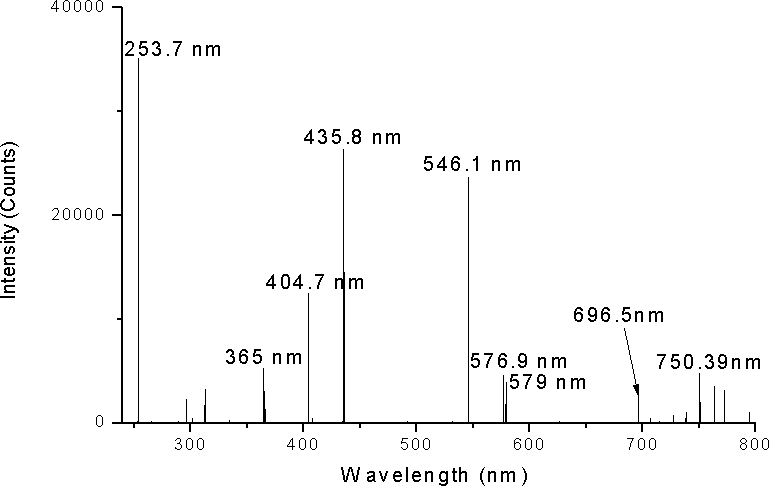

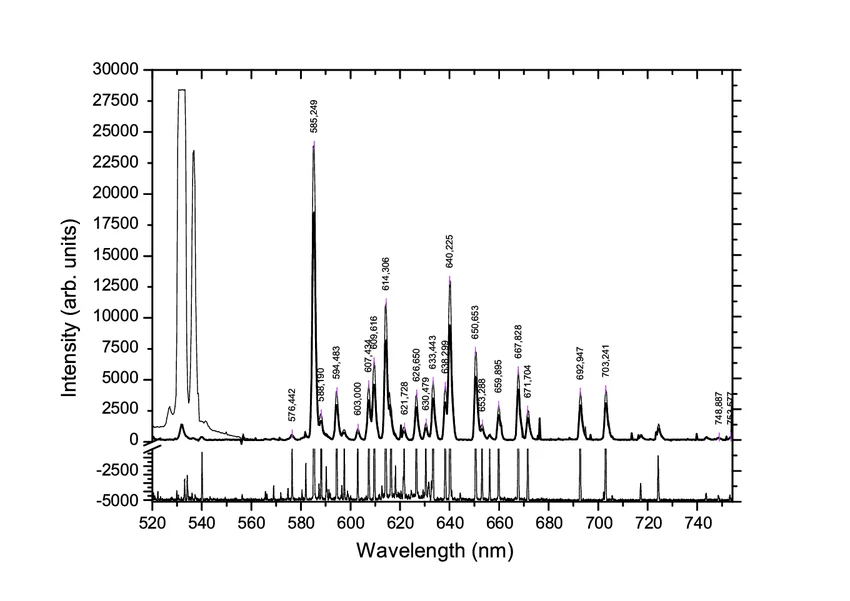

| Raie | Longueur d’onde (nm) | Élément associé | Couleur |
|---|---:|---|---|
| 404.656 | 404.656 | Hg | bleu |
| 407.781 | 407.781 | Hg | bleu |
| 435.835 | 435.835 | Hg | bleu |
| 491.604 | 491.604 | Hg | bleu |
| 546.074 | 546.074 | Hg | vert |
| 576.959 | 576.959 | Hg | jaune-orangé |
| 579.065 | 579.065 | Hg | jaune-orangé |
| 540.1 | 540.1 | Ne | vert |
| 585.2 | 585.2 | Ne | jaune |
| 588.2 | 588.2 | Ne | jaune |
| 603.0 | 603.0 | Ne | orange |
| 607.4 | 607.4 | Ne | orange |
| 616.4 | 616.4 | Ne | orange |
| 621.7 | 621.7 | Ne | rouge-orangé |
| 626.6 | 626.6 | Ne | rouge-orangé |
| 633.4 | 633.4 | Ne | rouge |
| 638.3 | 638.3 | Ne | rouge |
| 640.2 | 640.2 | Ne | rouge |
| 650.6 | 650.6 | Ne | rouge |
| 659.9 | 659.9 | Ne | rouge |
| 692.9 | 692.9 | Ne | rouge |
| 703.2 | 703.2 | Ne | rouge |

**Remarque :** les raies à 404.656, 407.781, 435.835, 491.604, 546.074, 576.959 et 579.065 nm sont généralement attribuées au mercure, tandis que les autres correspondent au néon.
red